# Endpoint Finder V2
Regress track endpoints using `EndpointRegressor` and shared graph utilities.
This notebook implements the training loop for finding the start and end points of particle tracks.

In [1]:
import sys, os
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
from torch_geometric.data import Batch
from typing import List, Dict, Any, Optional, Tuple
import glob
import re
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from IPython.display import clear_output
import heapq

# Add parent directory to path to import graph_data modules
sys.path.append(os.path.abspath(''))

from graph_data.utils import GraphGroupDataset, GraphRecord, NUM_GROUP_CLASSES
from graph_data.models import EndpointRegressor
from graph_data.plotting import plot_event_display

/home/omar/miniconda3/envs/research/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
def load_endpoint_groups(
    npy_files: List[str],
    verbose: bool = True,
    limit_groups: Optional[int] = None
) -> List[GraphRecord]:
    records = []
    
    if verbose:
        print(f"Found {len(npy_files)} hit files. Starting processing...")
    
    # Sort files by index
    def extract_index(fname):
        match = re.search(r'hits_batch_(\d+)\.npy', fname)
        return int(match.group(1)) if match else -1
    
    paths = sorted(npy_files, key=extract_index)
    
    for path in tqdm(paths, desc="Processing Files", disable=not verbose):
        try:
            chunk_data = np.load(path, allow_pickle=True)
            # Load corresponding group info for event ID and endpoints
            batch_idx = extract_index(path)
            info_path = path.replace(f"hits_batch_{batch_idx}.npy", f"group_info_batch_{batch_idx}.npy")
            info_data = np.load(info_path, allow_pickle=True)
        except Exception as e:
            print(f"Error loading {path}: {e}")
            continue

        if limit_groups and len(records) >= limit_groups:
            break
            
        chunk_index = extract_index(path)
        
        for group_offset, (group, g_info) in enumerate(zip(chunk_data, info_data)):
            if limit_groups and len(records) >= limit_groups:
                break
                
            # group is a numpy array of hits (or list of lists, so convert)
            # hit structure: [coord, z, stripType, energySmeared, pdg_binary]
            
            if len(group) < 2:
                continue
                
            group = np.array(group)
            
            # Extract features
            coord = group[:, 0].astype(np.float32)
            z_pos = group[:, 1].astype(np.float32)
            view_flag = group[:, 2].astype(np.float32)
            energy = group[:, 3].astype(np.float32)
            
            # Extract True Start/End from group_info
            # group_info indices:
            # 0-2: flags
            # 3-5: pion stop
            # 6-8: energies
            # 9: theta, 10: phi, 11: eventID
            # 12-14: startX, startY, startZ
            # 15-17: endX, endY, endZ
            
            if len(g_info) >= 18:
                true_start = [g_info[12], g_info[13], g_info[14]]
                true_end = [g_info[15], g_info[16], g_info[17]]
            else:
                # Fallback or skip if data not regenerated yet
                continue
            
            # Calculate class energies for group_energy feature (data.u)
            # We need hit labels for this
            hit_masks = group[:, 4].astype(int) # Index 4 is pdg_binary
            
            is_pion = (hit_masks & 1) != 0
            is_muon = (hit_masks & 2) != 0
            is_mip = ((hit_masks & 4) != 0) | ((hit_masks & 8) != 0)
            
            hit_labels = np.stack([is_pion, is_muon, is_mip], axis=1).astype(np.float32)
            class_energies = hit_labels.T @ energy

            # Event ID from group_info (index 11)
            # group_info: [..., eventID]
            record_event_id = int(g_info[11])

            records.append(GraphRecord(
                coord=coord,
                z=z_pos,
                view=view_flag,
                energy=energy,
                class_energies=class_energies,
                true_start=true_start,
                true_end=true_end,
                event_id=record_event_id,
                group_id=len(records)
            ))
            
        if limit_groups and len(records) >= limit_groups:
            break
            
    if verbose:
        print(f"Loaded {len(records)} groups.")
        
    return records

In [3]:
def compute_position_loss_and_error(output, target, loss_scale=1.0, loss_scale_z=0.0):
    """
    output and target should both be of shape [batch_size, 2, 3]
    Calculates permutation-invariant MSE loss.
    Returns: loss, mean_error, error_per_sample
    """
    # Option 1: output[0] <-> target[0], output[1] <-> target[1]
    loss_a = F.mse_loss(output[:, 0], target[:, 0], reduction='none').sum(dim=1) + \
             F.mse_loss(output[:, 1], target[:, 1], reduction='none').sum(dim=1)

    # Option 2: output[0] <-> target[1], output[1] <-> target[0]
    loss_b = F.mse_loss(output[:, 0], target[:, 1], reduction='none').sum(dim=1) + \
             F.mse_loss(output[:, 1], target[:, 0], reduction='none').sum(dim=1)

    # Choose best permutation
    swap = loss_b < loss_a
    aligned_output = output.clone()
    aligned_output[swap] = output[swap][:, [1, 0], :]

    # Pointwise loss (min of permutations)
    point_loss = torch.min(loss_a, loss_b).mean()

    # Auxiliary losses
    true_span = (target[:, 1] - target[:, 0]).norm(dim=1)
    pred_span = (aligned_output[:, 1] - aligned_output[:, 0]).norm(dim=1)
    span_loss = F.mse_loss(pred_span, true_span)

    true_z_span = torch.abs(target[:, 1, 2] - target[:, 0, 2])
    pred_z_span = torch.abs(aligned_output[:, 1, 2] - aligned_output[:, 0, 2])
    z_loss = F.mse_loss(pred_z_span, true_z_span)

    loss = point_loss + loss_scale * span_loss + loss_scale_z * z_loss * (1 + z_loss)

    # Also compute Euclidean error per match
    # Divide by 2 to get average error per endpoint
    error_per_sample = ((aligned_output[:, 0] - target[:, 0]).norm(dim=1) + \
                       (aligned_output[:, 1] - target[:, 1]).norm(dim=1)) / 2.0
    
    mean_error = error_per_sample.mean()

    return loss, mean_error, error_per_sample

In [4]:
def plot_error_distributions(errors_by_class, epoch):
    plt.figure(figsize=(15, 5))
    class_names = {0: 'Pion', 1: 'Muon', 2: 'MIP'}
    
    for cls, errs in errors_by_class.items():
        if not errs: continue
        plt.subplot(1, 3, cls + 1)
        plt.hist(errs, bins=100, range=(0, 2), alpha=0.7, label=f'{class_names[cls]} (N={len(errs)})')
        plt.title(f'{class_names[cls]} Mean Endpoint Error (Epoch {epoch})')
        plt.xlabel('Mean Error (mm)')
        plt.ylabel('Count')
        plt.legend()
        
    plt.tight_layout()
    plt.show()

In [5]:
def train_endpoint(
    groups: List[GraphRecord],
    *,
    model: Optional[EndpointRegressor] = None,
    batch_size: int = 64,
    epochs: int = 20,
    lr: float = 1e-3,
    device: Optional[str] = None,
    grad_clip: Optional[float] = None,
):
    if not groups:
        raise ValueError('No groups provided for training.')

    device_str = device or ('cuda' if torch.cuda.is_available() else 'cpu')
    device_obj = torch.device(device_str)
    print(f"Using device: {device_obj}")

    # Split data
    rng = np.random.default_rng(42)
    indices = rng.permutation(len(groups))
    train_size = int(len(groups) * 0.9)
    train_idx, val_idx = indices[:train_size], indices[train_size:]
    
    train_groups = [groups[i] for i in train_idx]
    val_groups = [groups[i] for i in val_idx]
    
    train_dataset = GraphGroupDataset(train_groups)
    val_dataset = GraphGroupDataset(val_groups) if val_groups else None
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False) if val_dataset else None

    model = model.to(device_obj) if model else EndpointRegressor(in_channels=4).to(device_obj)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        total_error = 0.0
        
        for batch in train_loader:
            batch = batch.to(device_obj)
            optimizer.zero_grad()
            
            # Forward pass
            out = model(batch) # [batch_size, 2, 3]
            
            if not hasattr(batch, 'y_pos'):
                continue
                
            target = batch.y_pos.view(-1, 2, 3) # Reshape to [batch_size, 2, 3]
            
            loss, mean_error, _ = compute_position_loss_and_error(out, target)
            
            loss.backward()
            if grad_clip is not None:
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()
            
            total_loss += loss.item() * batch.num_graphs
            total_error += mean_error.item() * batch.num_graphs
            
        avg_loss = total_loss / len(train_groups)
        avg_error = total_error / len(train_groups)
        
        print(f"Epoch {epoch:02d} | Train Loss: {avg_loss:.4f} | Mean Error: {avg_error:.4f}")
        
        if val_loader:
            model.eval()
            val_loss = 0.0
            val_error = 0.0
            
            # Error tracking per class
            # Classes: 0=Pion, 1=Muon, 2=MIP
            errors_by_class = {0: [], 1: [], 2: []}
            
            with torch.no_grad():
                for batch in val_loader:
                    batch = batch.to(device_obj)
                    out = model(batch)
                    target = batch.y_pos.view(-1, 2, 3)
                    
                    loss, mean_error, sample_errors = compute_position_loss_and_error(out, target)
                    
                    val_loss += loss.item() * batch.num_graphs
                    val_error += mean_error.item() * batch.num_graphs
                    
                    # Determine class from y_energy
                    if hasattr(batch, 'y_energy'):
                        # y_energy shape: [batch_size, 3]
                        # Get dominant class
                        classes = torch.argmax(batch.y_energy, dim=1).cpu().numpy()
                        errs = sample_errors.cpu().numpy()
                        
                        for cls, err in zip(classes, errs):
                            if cls in errors_by_class:
                                errors_by_class[cls].append(err)
            
            avg_val_loss = val_loss / len(val_groups)
            avg_val_error = val_error / len(val_groups)
            print(f"         | Val Loss: {avg_val_loss:.4f} | Val Error: {avg_val_error:.4f}")
            
            scheduler.step(avg_val_loss)
            
            # Plot error distributions
            plot_error_distributions(errors_by_class, epoch)
            
    return model

In [6]:
data_dir = "npy_data"
npy_files = glob.glob(os.path.join(data_dir, "hits_batch_*.npy"))

# Load groups
groups = load_endpoint_groups(npy_files, limit_groups=100000)

Found 289 hit files. Starting processing...


Processing Files:   0%|          | 0/289 [00:00<?, ?it/s]

Processing Files:   3%|▎         | 10/289 [02:28<1:09:12, 14.88s/it]

Loaded 100000 groups.


In [ ]:
model = EndpointRegressor(in_channels=4, hidden=100, heads=5,
                 layers=2, dropout=0.05)

Using device: cuda
Epoch 01 | Train Loss: 12.5360 | Mean Error: 1.5039
         | Val Loss: 5.5206 | Val Error: 0.9759


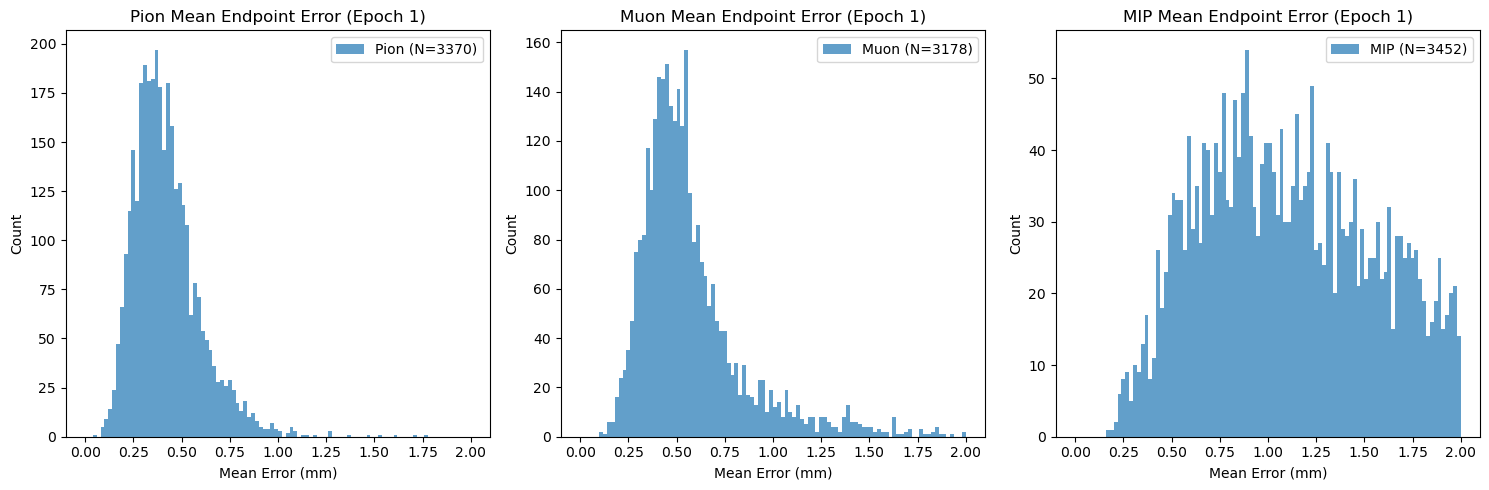

Epoch 02 | Train Loss: 4.7180 | Mean Error: 0.8845
         | Val Loss: 4.1103 | Val Error: 0.7888


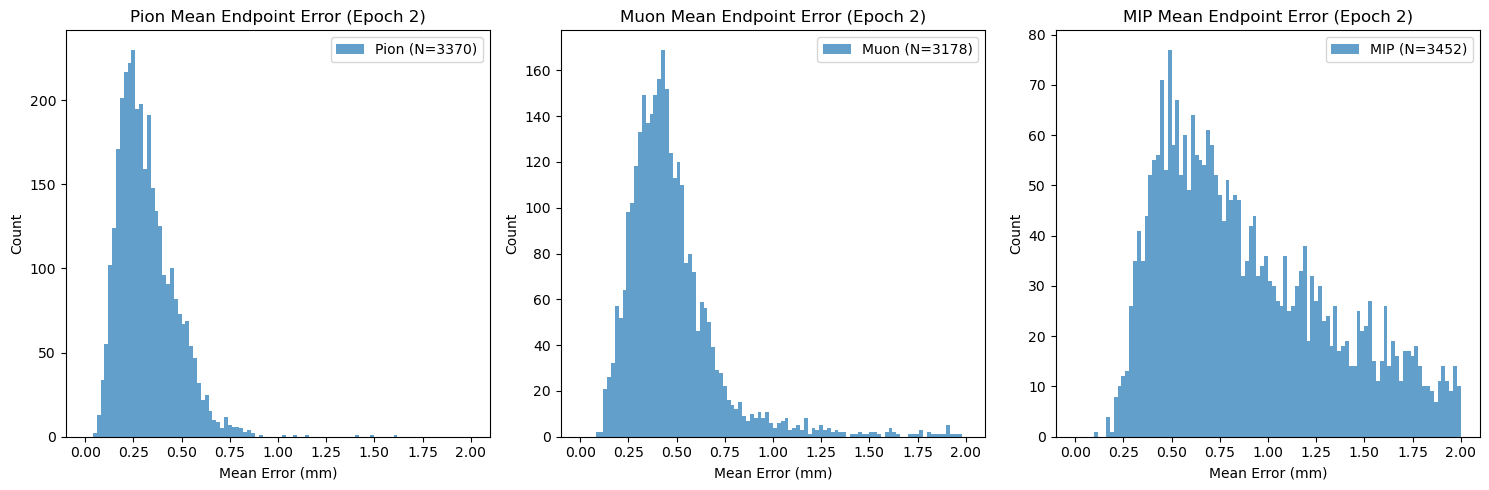

Epoch 03 | Train Loss: 3.7239 | Mean Error: 0.7497
         | Val Loss: 3.2367 | Val Error: 0.6523


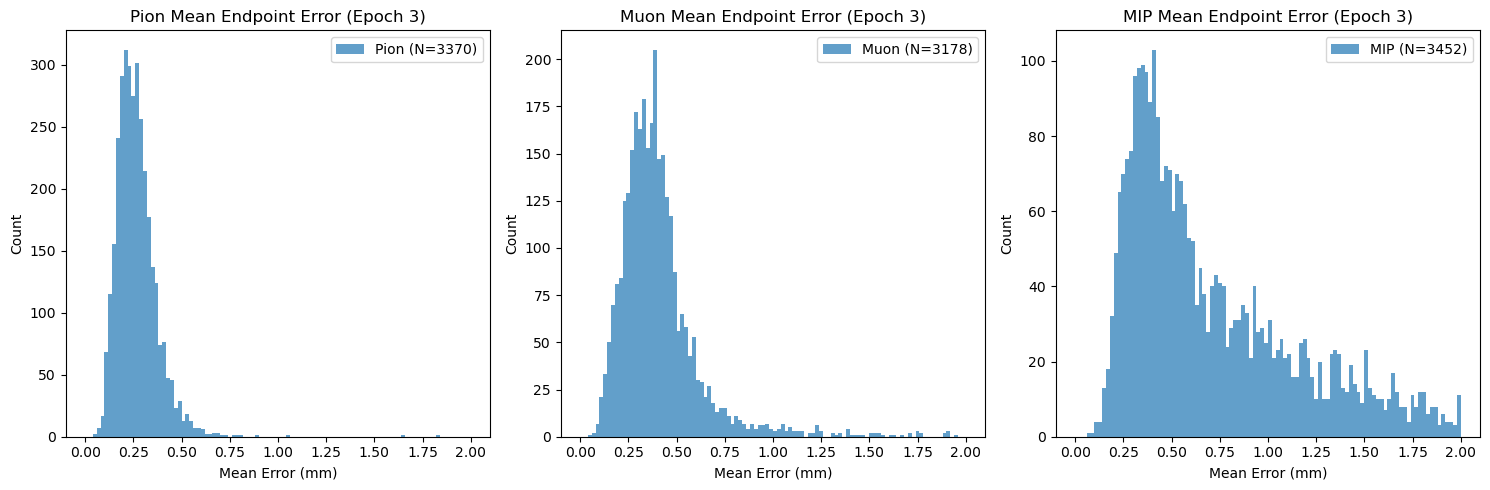

Epoch 04 | Train Loss: 3.3316 | Mean Error: 0.6806
         | Val Loss: 3.1018 | Val Error: 0.6427


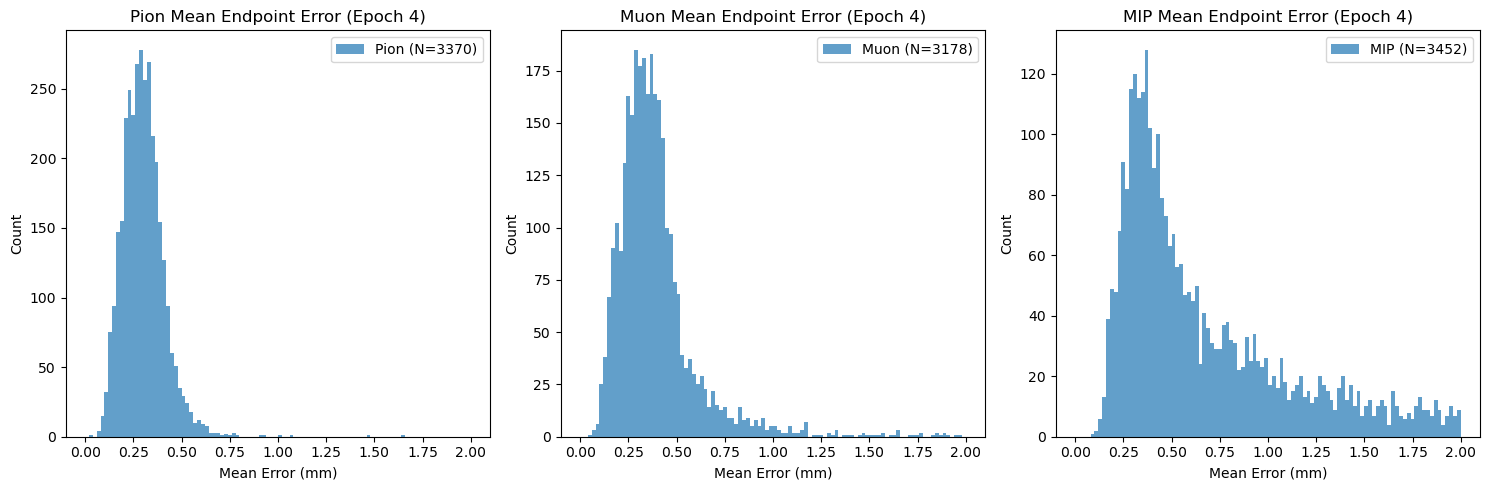

Epoch 05 | Train Loss: 3.1458 | Mean Error: 0.6602
         | Val Loss: 3.2282 | Val Error: 0.6503


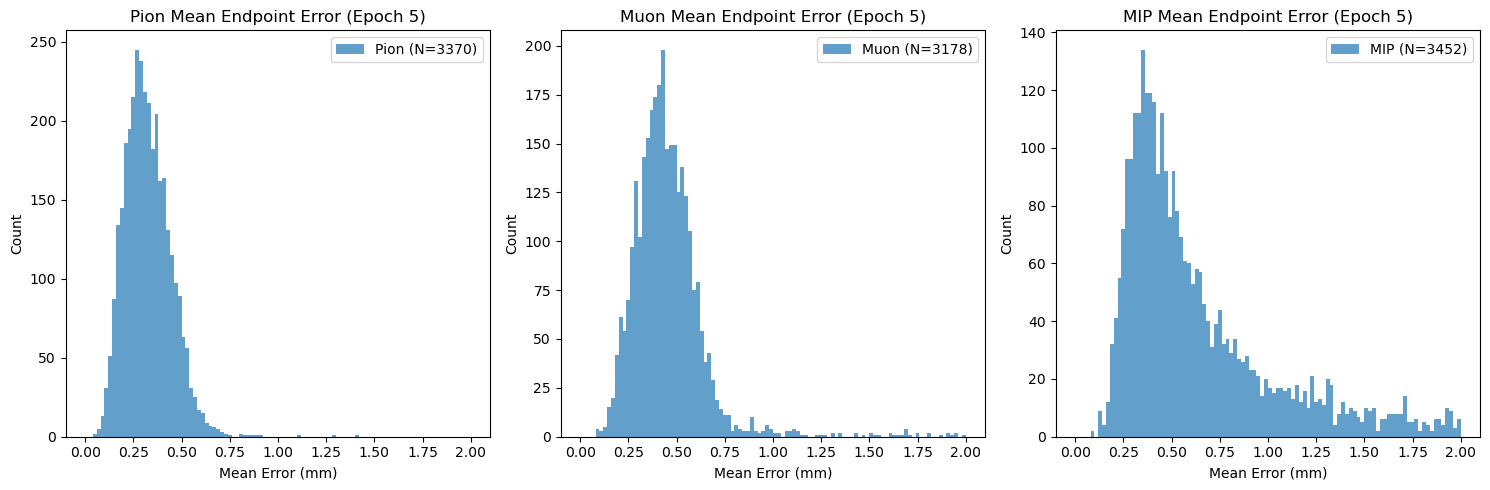

Epoch 06 | Train Loss: 2.9425 | Mean Error: 0.6232
         | Val Loss: 2.8605 | Val Error: 0.5864


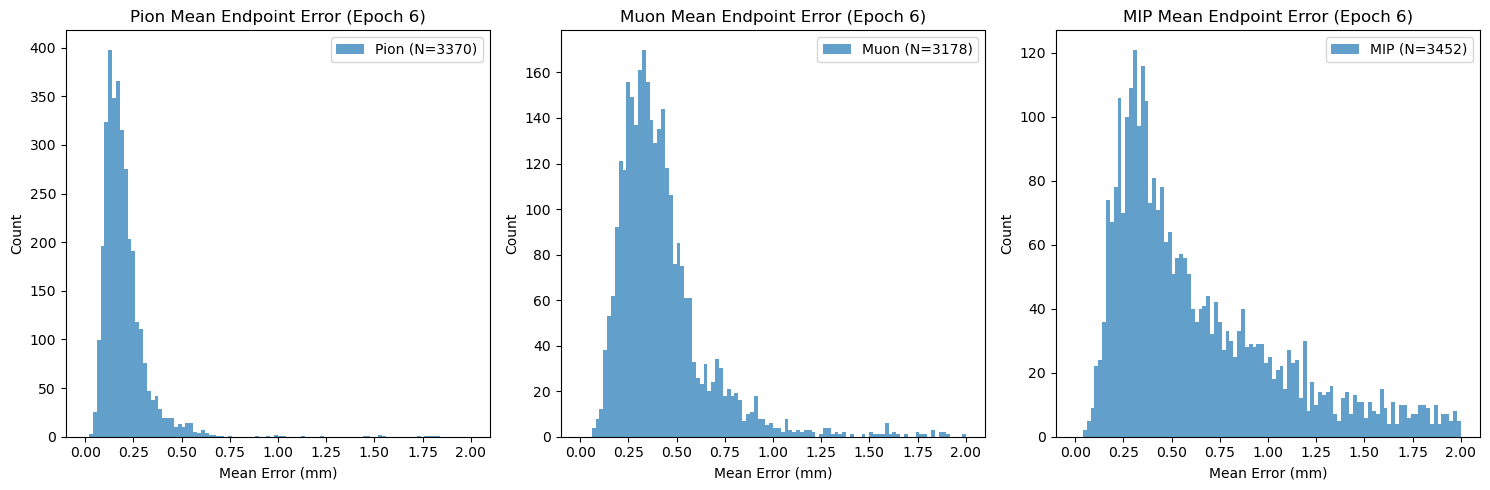

Epoch 07 | Train Loss: 2.8626 | Mean Error: 0.6057
         | Val Loss: 2.6302 | Val Error: 0.5378


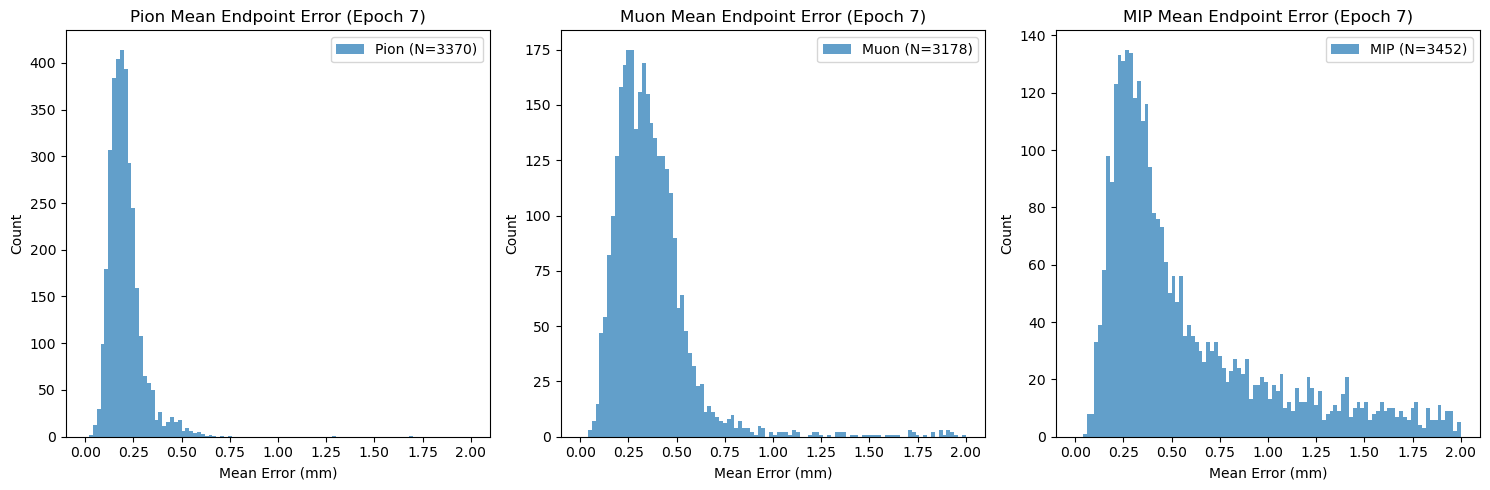

Epoch 08 | Train Loss: 2.6850 | Mean Error: 0.5811
         | Val Loss: 2.2739 | Val Error: 0.5029


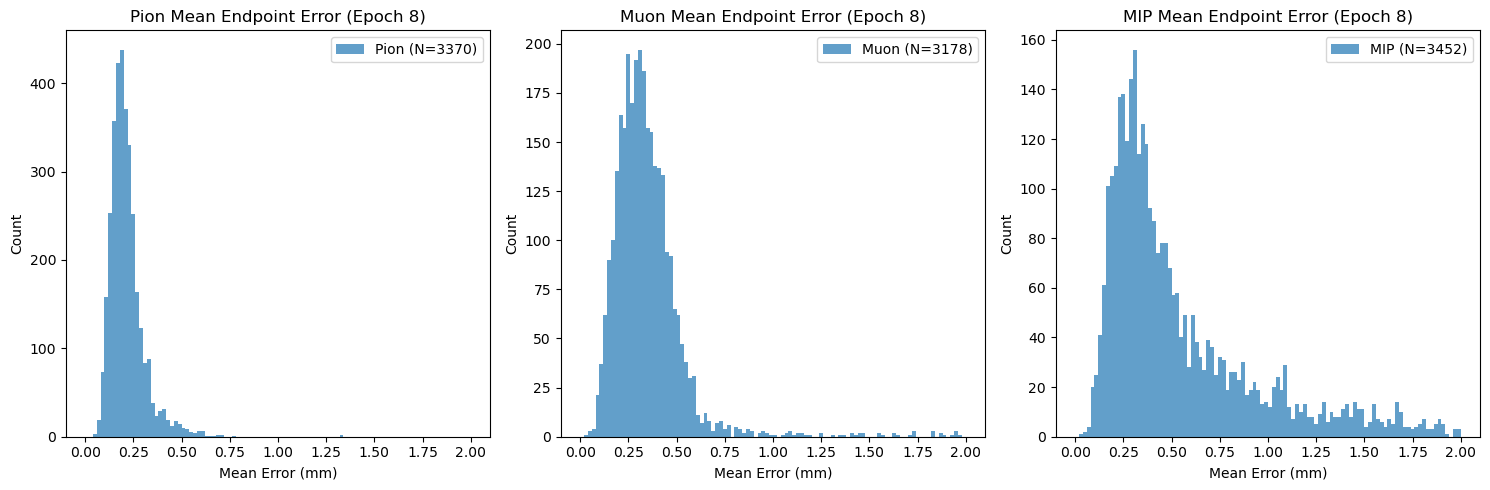

Epoch 09 | Train Loss: 2.6353 | Mean Error: 0.5734
         | Val Loss: 2.5839 | Val Error: 0.5410


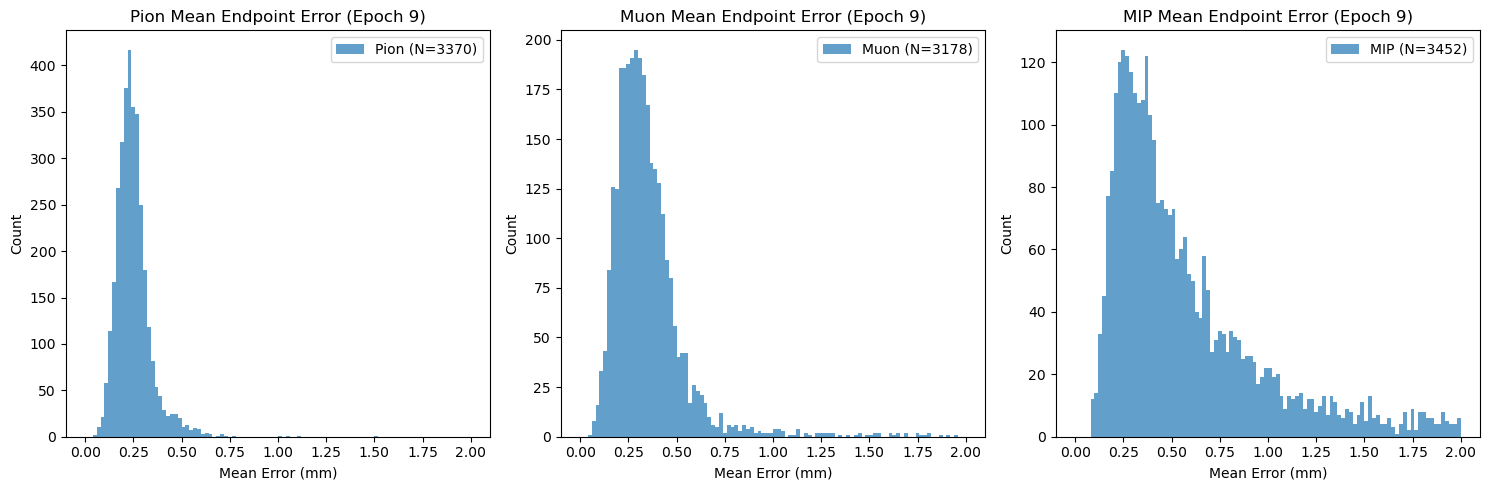

Epoch 10 | Train Loss: 2.6084 | Mean Error: 0.5643
         | Val Loss: 2.4206 | Val Error: 0.5119


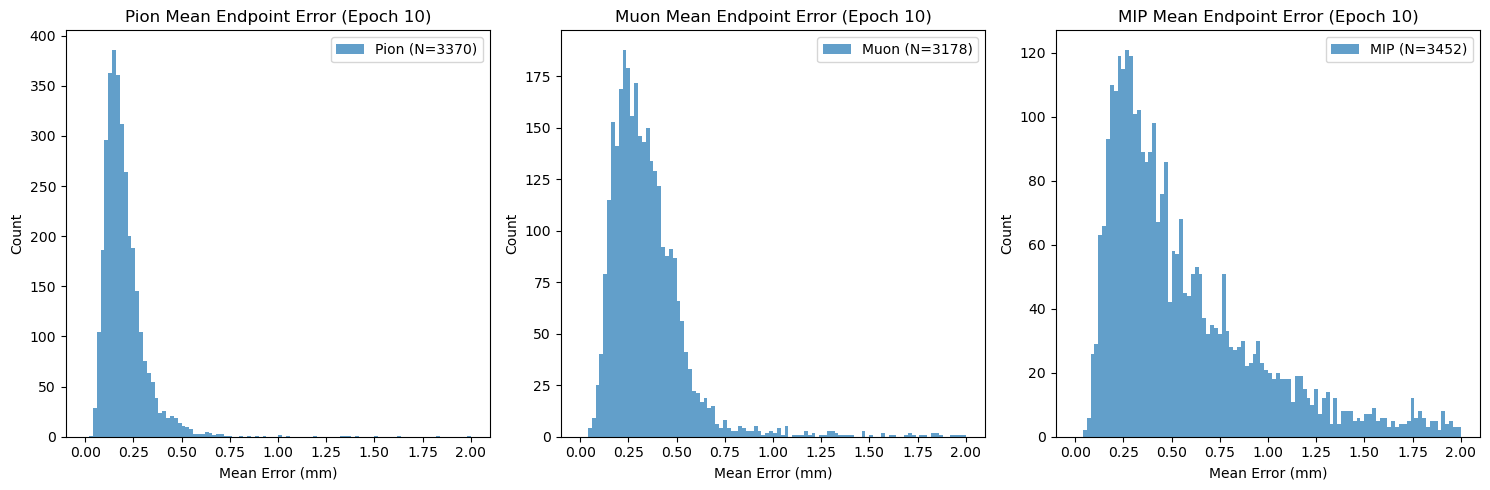

Epoch 11 | Train Loss: 2.4827 | Mean Error: 0.5479
         | Val Loss: 2.9251 | Val Error: 0.6220


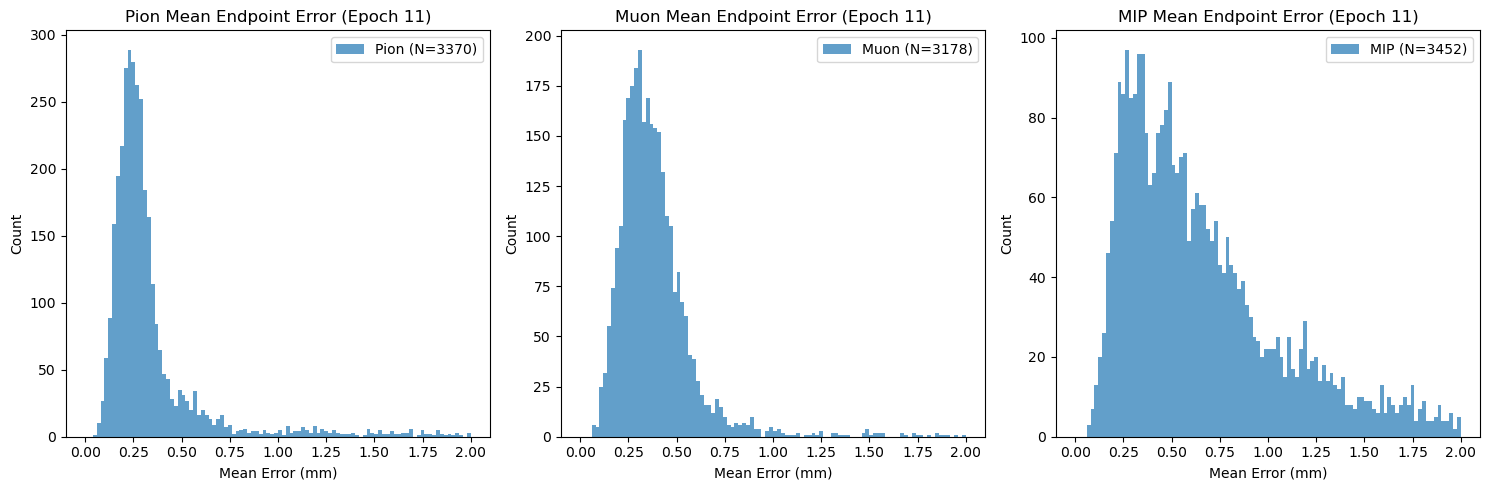

KeyboardInterrupt: 

In [ ]:
# Train
model = train_endpoint(groups, model=model, epochs=40, batch_size=16, lr=1e-4)

In [9]:
def visualize_failures(model, loader, device, num_failures=5):
    """
    Runs inference on the loader, tracks errors, and visualizes the worst failures
    showing both True Endpoints AND Predicted Endpoints.
    """
    model.eval()
    failures = [] # Will store (error, record, prediction) tuples
    
    print("Scanning validation set for failures...")
    
    with torch.no_grad():
        for batch_idx, batch in enumerate(loader):
            batch = batch.to(device)
            out = model(batch)
            target = batch.y_pos.view(-1, 2, 3)
            
            _, _, sample_errors = compute_position_loss_and_error(out, target)
            
            errs = sample_errors.cpu().numpy()
            out_np = out.cpu().numpy() # Shape [Batch, 2, 3]
            
            # Map back to dataset records
            start_idx = batch_idx * loader.batch_size
            
            for i, error in enumerate(errs):
                dataset_idx = start_idx + i
                if dataset_idx >= len(loader.dataset): break
                
                # Fetch original record
                rec = loader.dataset.items[dataset_idx]
                
                # Prediction for this specific graph
                pred_endpoints = out_np[i] # Shape [2, 3] -> [[x1,y1,z1], [x2,y2,z2]]
                
                # Maintain top N failures
                if len(failures) < num_failures:
                    heapq.heappush(failures, (error, rec, pred_endpoints))
                else:
                    heapq.heappushpop(failures, (error, rec, pred_endpoints))
    
    # Sort failures descending by error
    failures.sort(key=lambda x: x[0], reverse=True)
    
    print(f"\nFound top {len(failures)} failures:")
    
    for i, (error, rec, pred) in enumerate(failures):
        print(f"\n--- Failure {i+1} ---")
        print(f"Error: {error:.4f} mm")
        print(f"Event ID: {rec.event_id}")
        
        title = f"Error: {error:.2f}mm | Event {rec.event_id}"
        
        # Pass prediction to plotter
        # We wrap 'pred' in a list because pred_points expects a list of predictions [N_preds, 2, 3]
        # Since we are plotting 1 record, we pass [pred].
        plot_event_display(
            rec,
            pred_points=[pred], 
            color_mode='pdg',
            title=title,
            show=True
        )


In [19]:
test_dataset = GraphGroupDataset(groups[:1000], num_classes=3)
test_loader = DataLoader(test_dataset, batch_size=100, shuffle=False)

Scanning validation set for failures...

Found top 35 failures:

--- Failure 1 ---
Error: 7.3178 mm
Event ID: 64


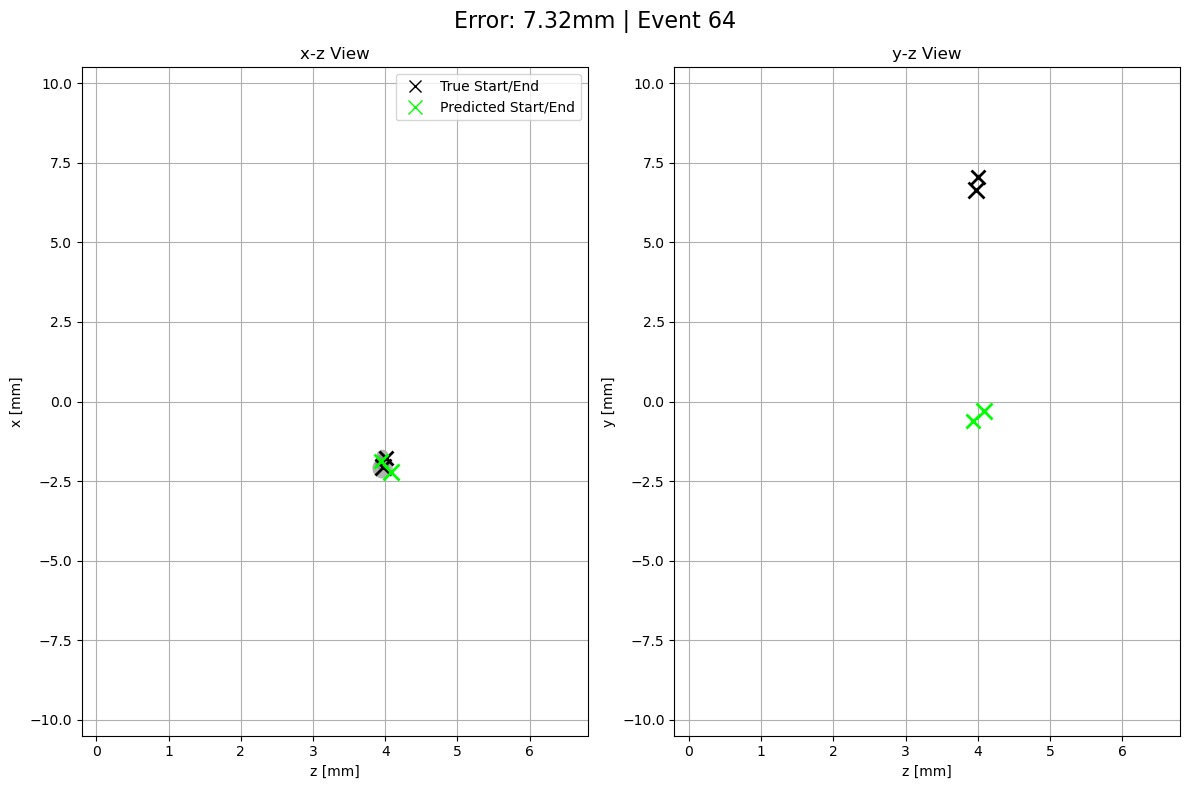


--- Failure 2 ---
Error: 6.4694 mm
Event ID: 267


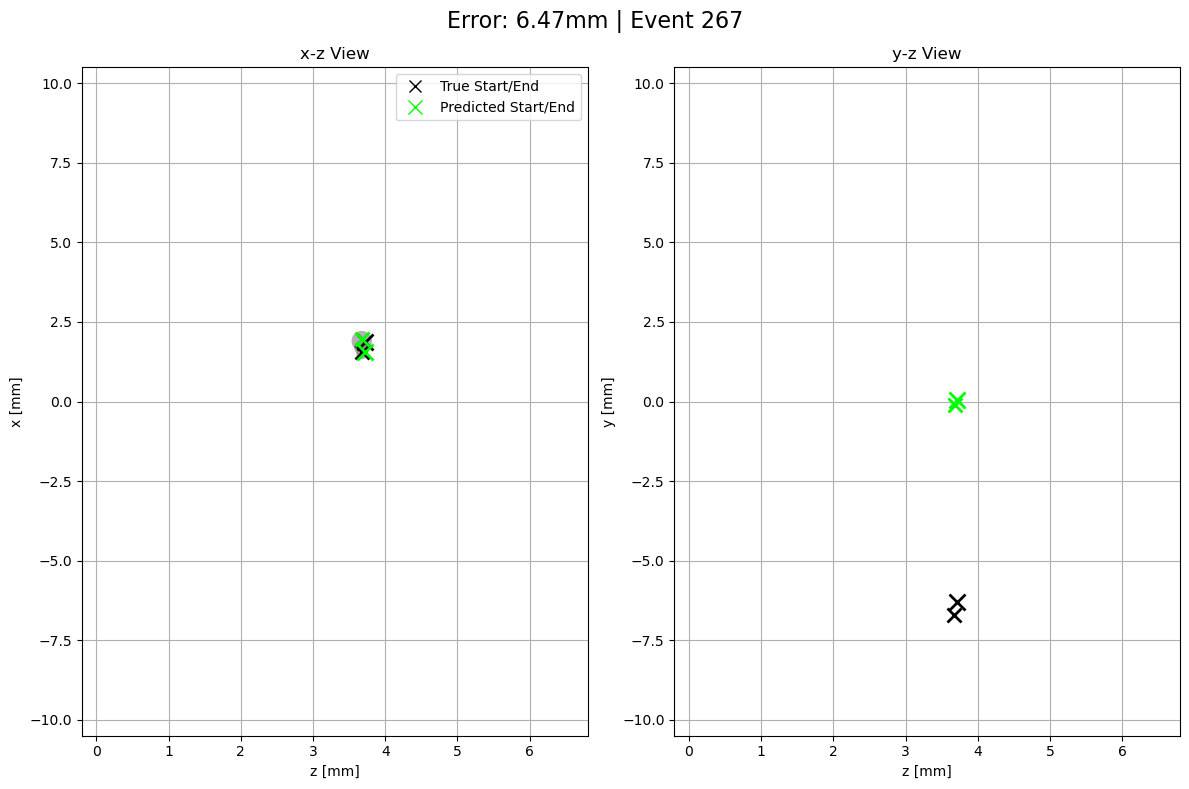


--- Failure 3 ---
Error: 5.9875 mm
Event ID: 99


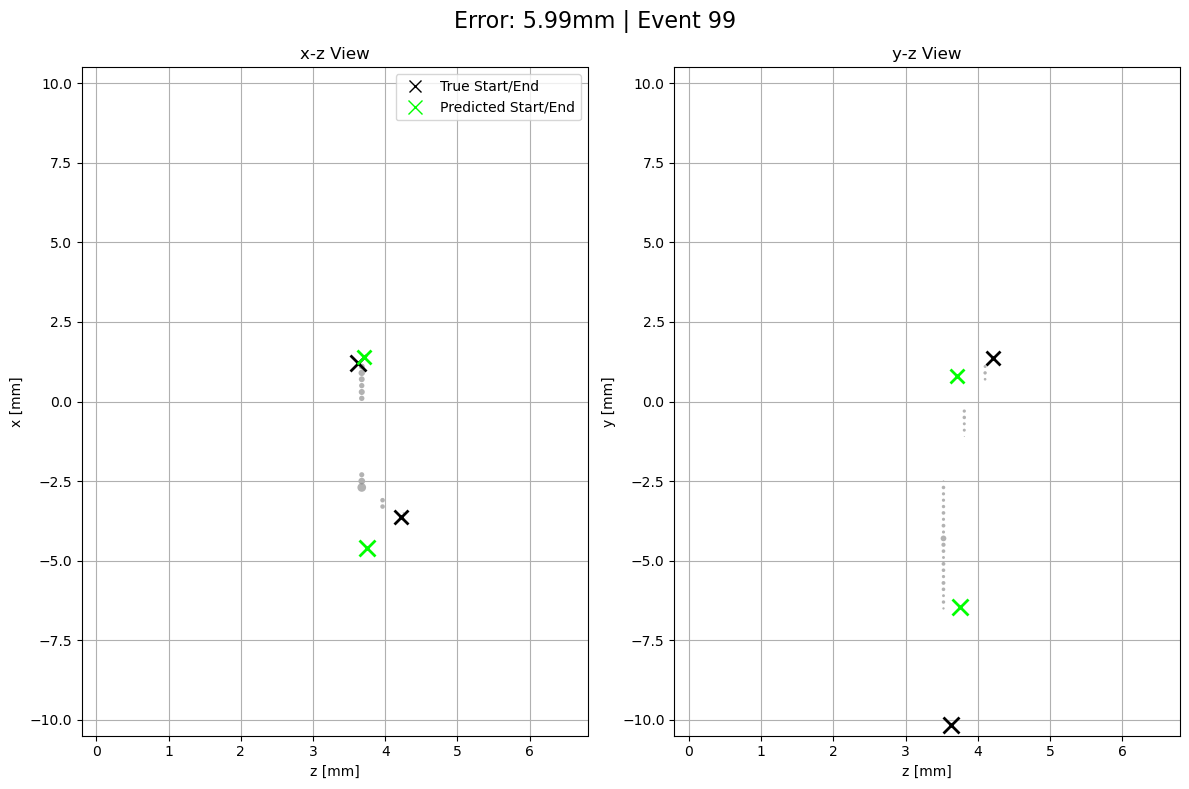


--- Failure 4 ---
Error: 5.9046 mm
Event ID: 125


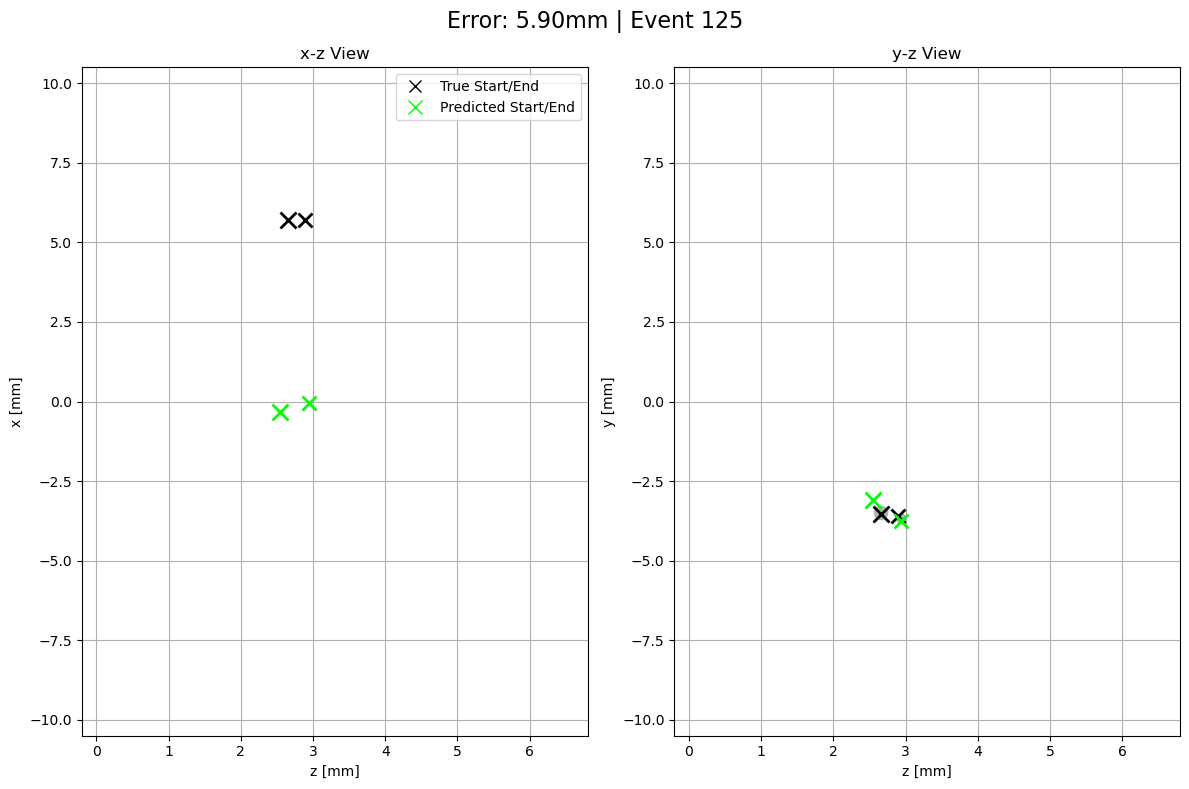


--- Failure 5 ---
Error: 5.5166 mm
Event ID: 38


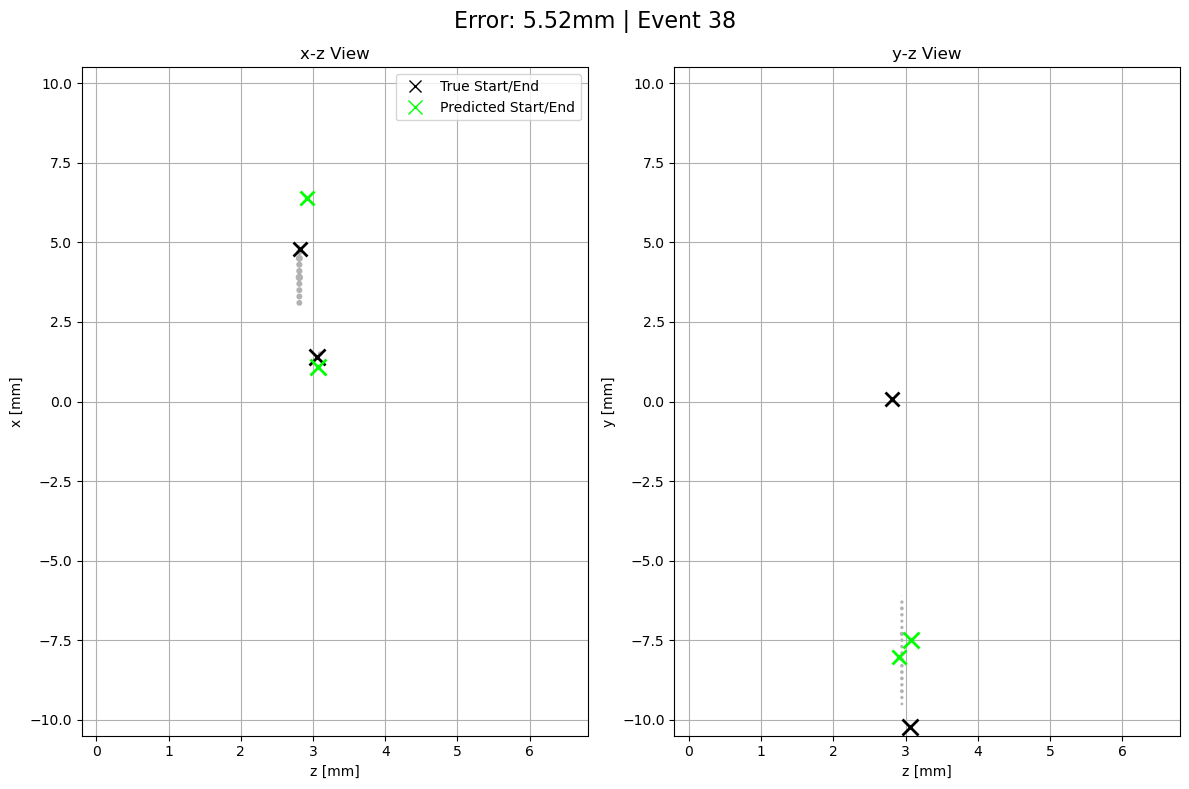


--- Failure 6 ---
Error: 4.9957 mm
Event ID: 259


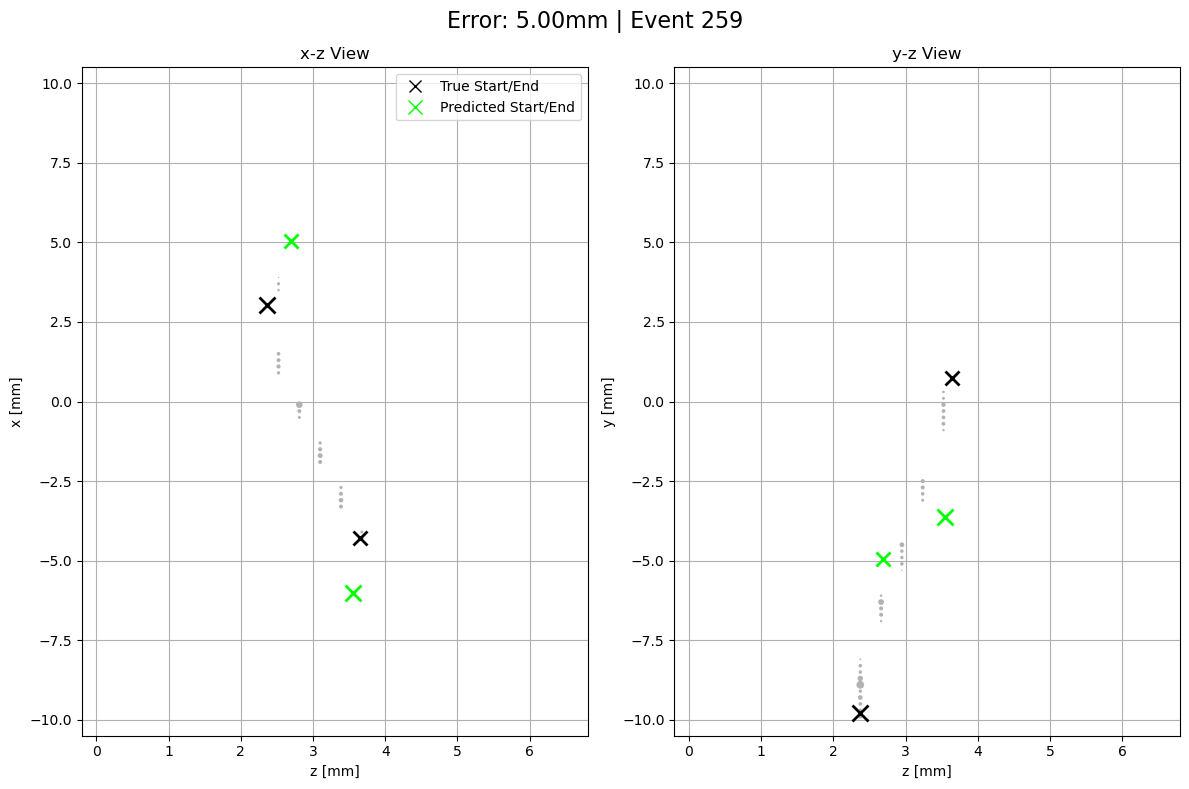


--- Failure 7 ---
Error: 4.9896 mm
Event ID: 72


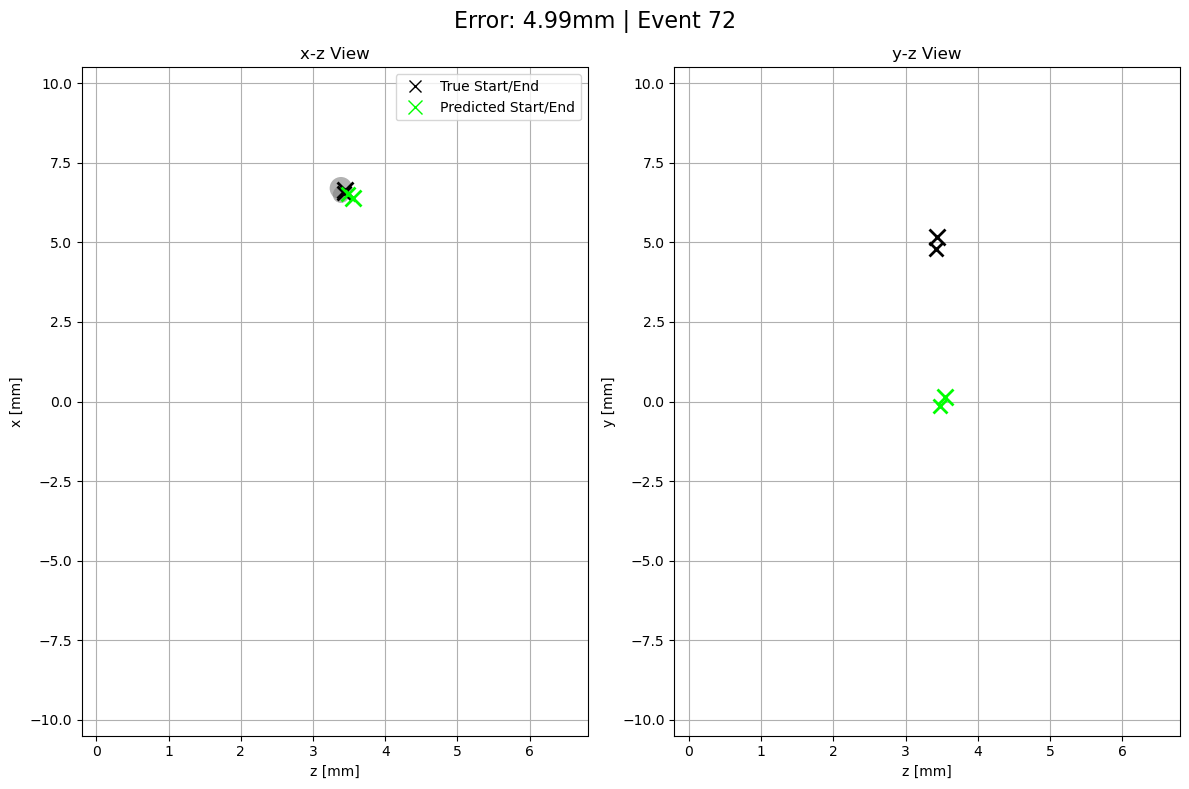


--- Failure 8 ---
Error: 4.9358 mm
Event ID: 97


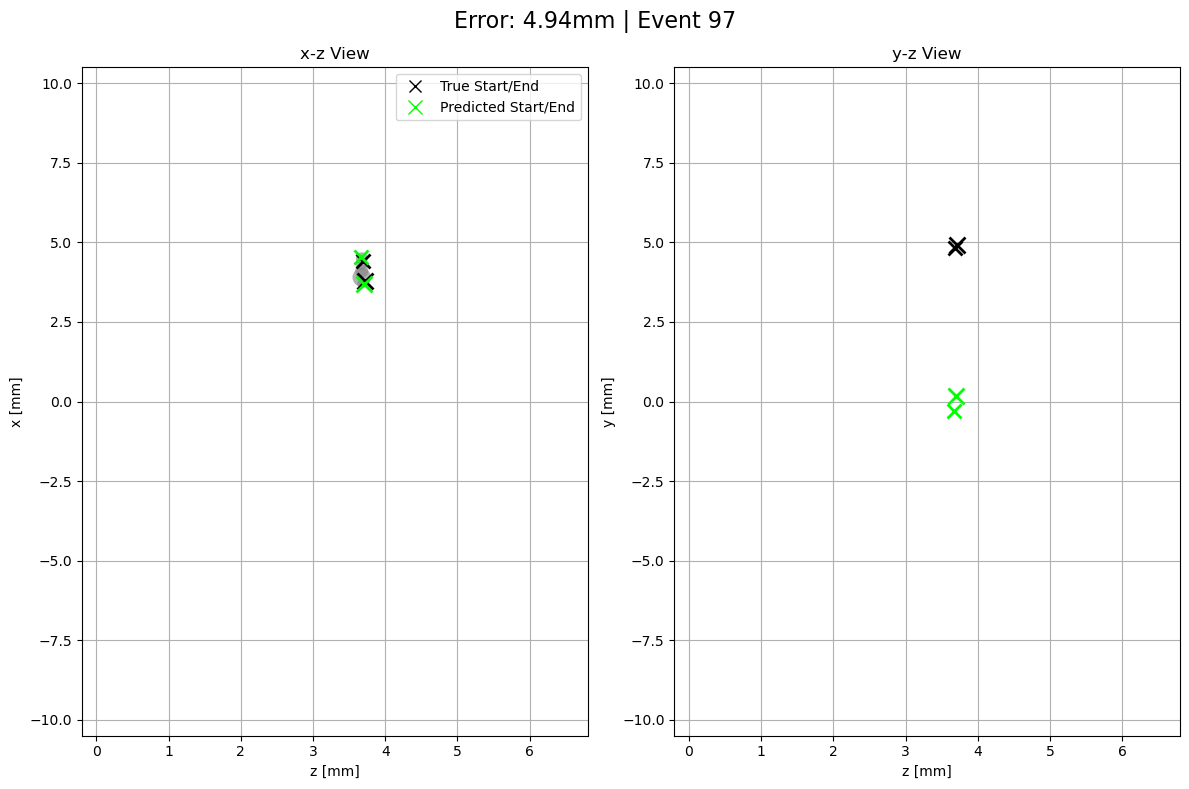


--- Failure 9 ---
Error: 4.7821 mm
Event ID: 255


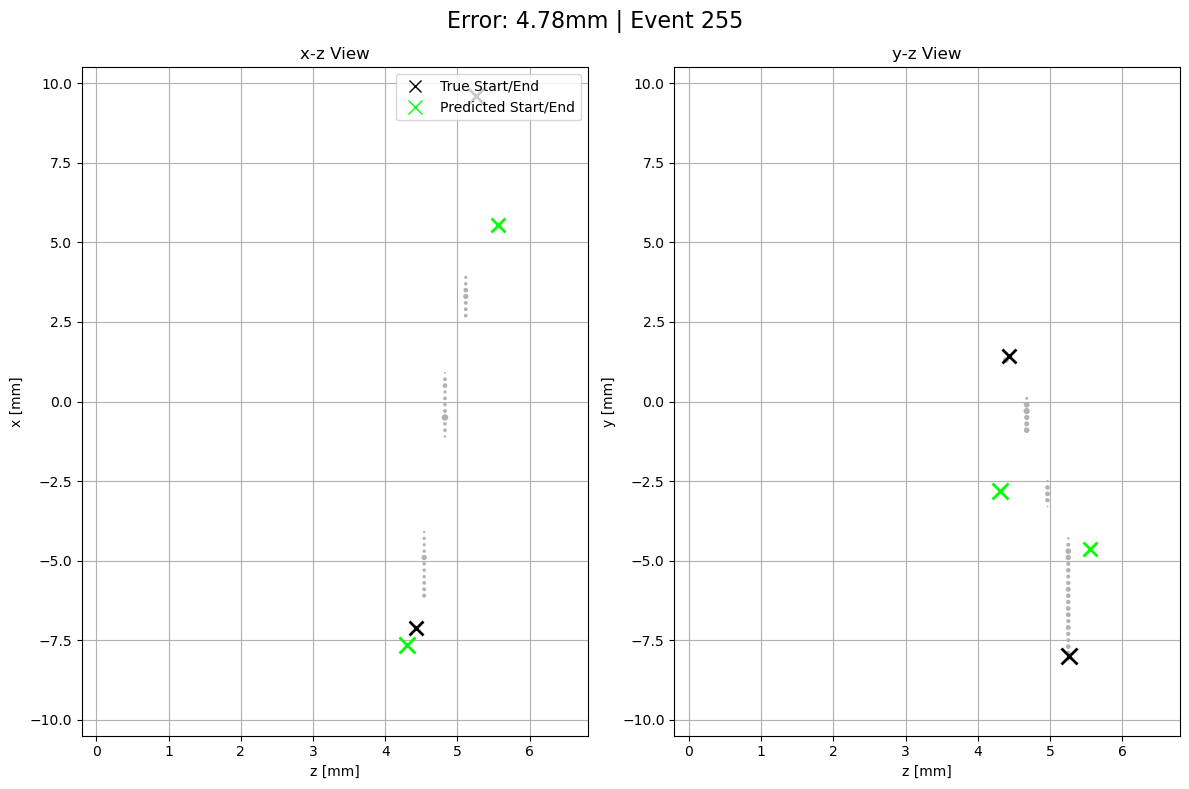


--- Failure 10 ---
Error: 4.7466 mm
Event ID: 9


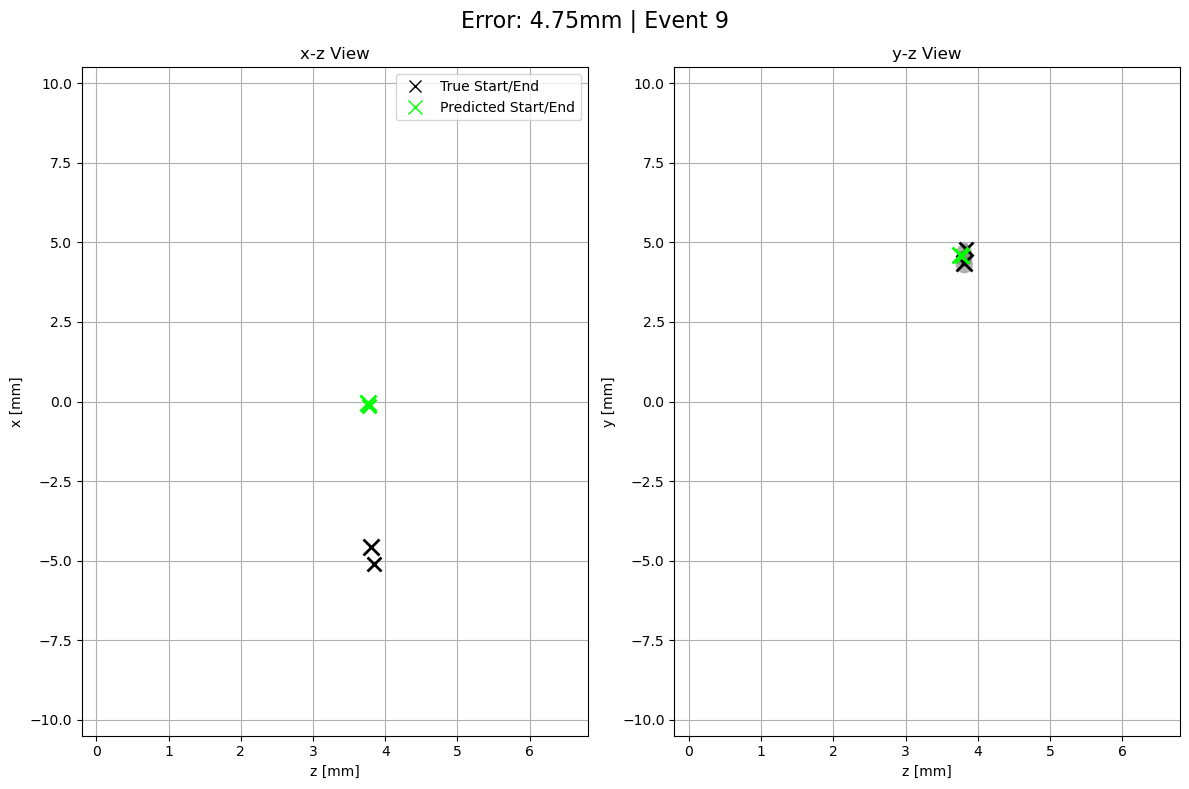


--- Failure 11 ---
Error: 4.6569 mm
Event ID: 149


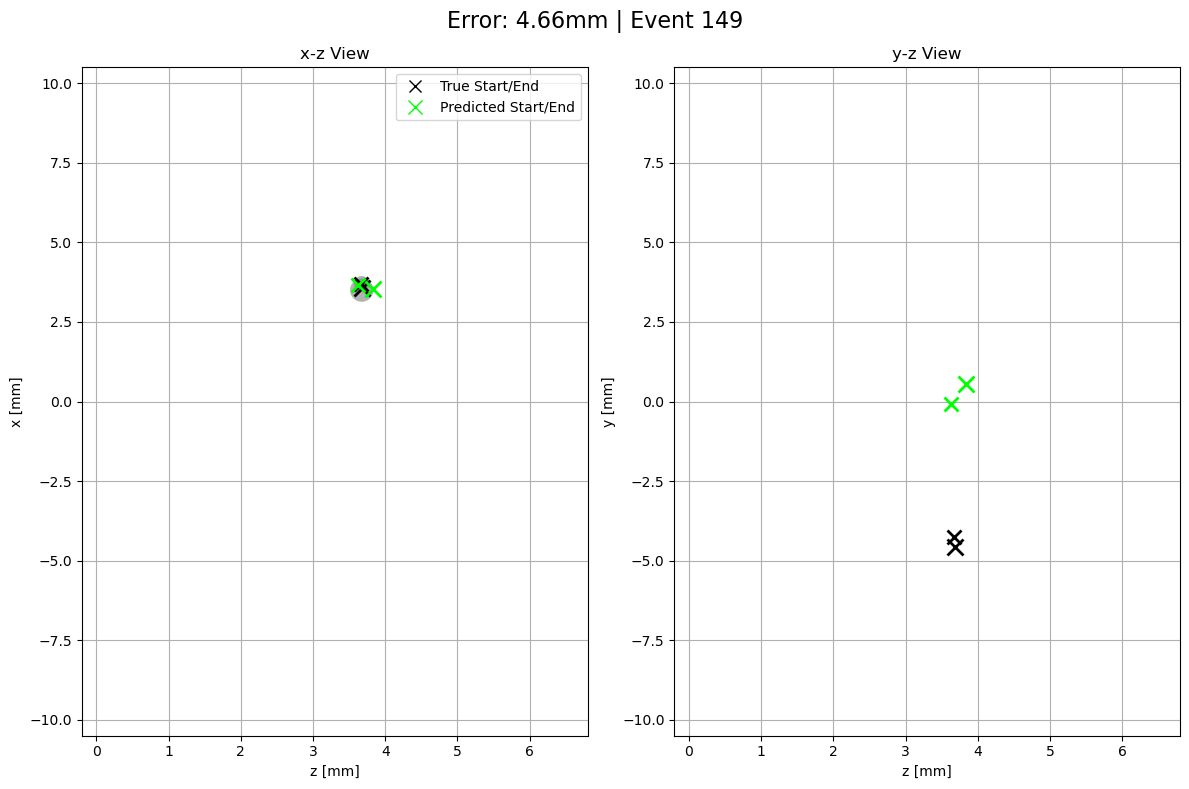


--- Failure 12 ---
Error: 4.5708 mm
Event ID: 175


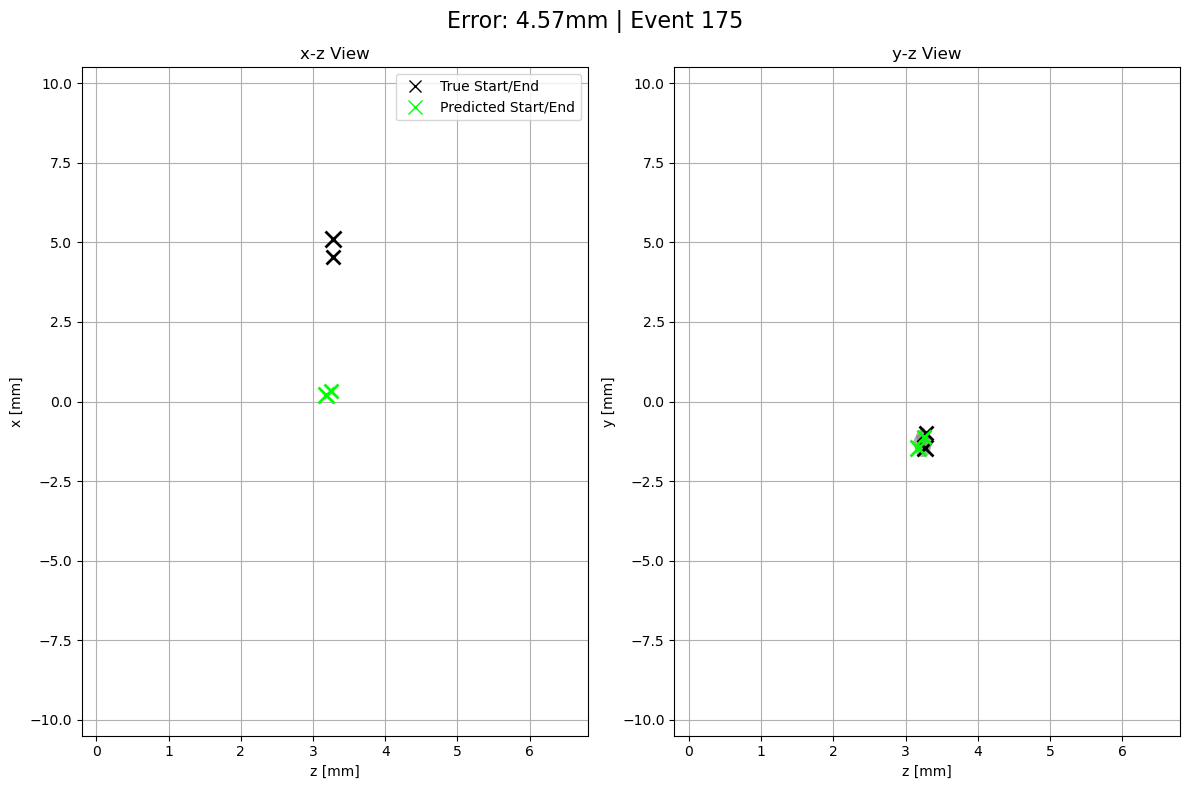


--- Failure 13 ---
Error: 4.5338 mm
Event ID: 294


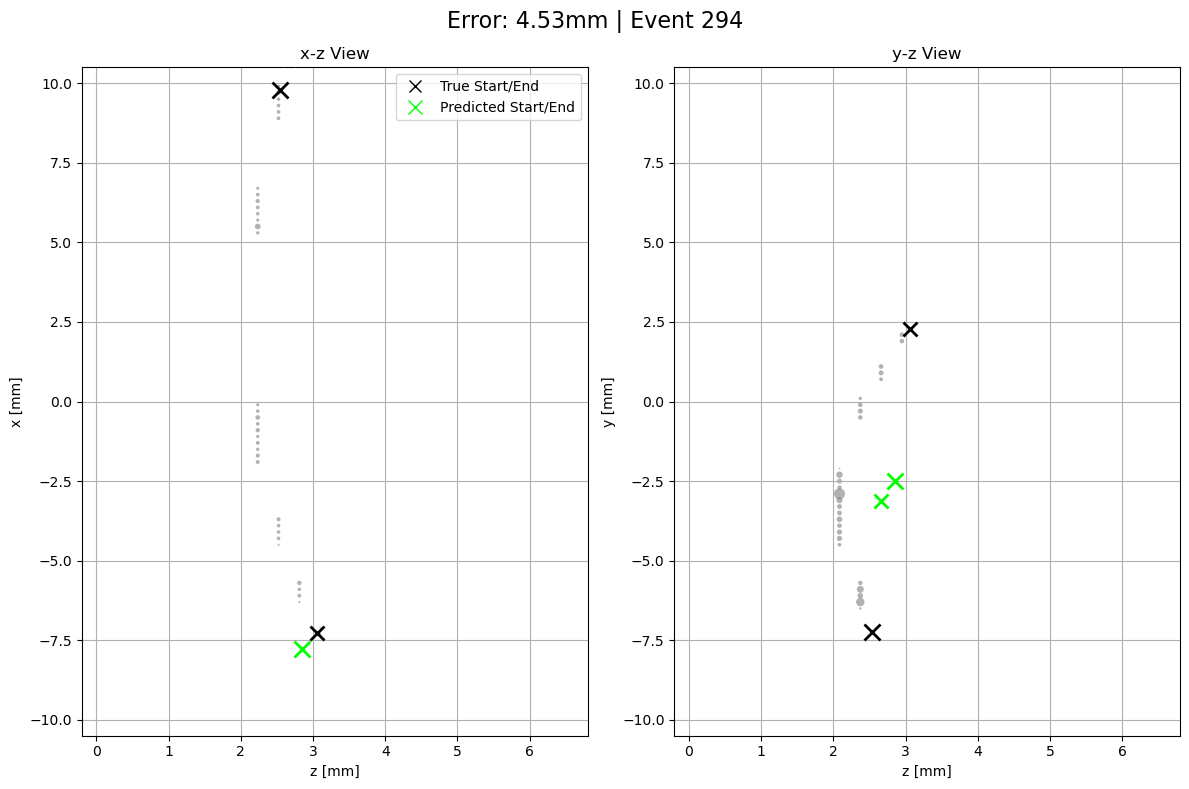


--- Failure 14 ---
Error: 4.0678 mm
Event ID: 67


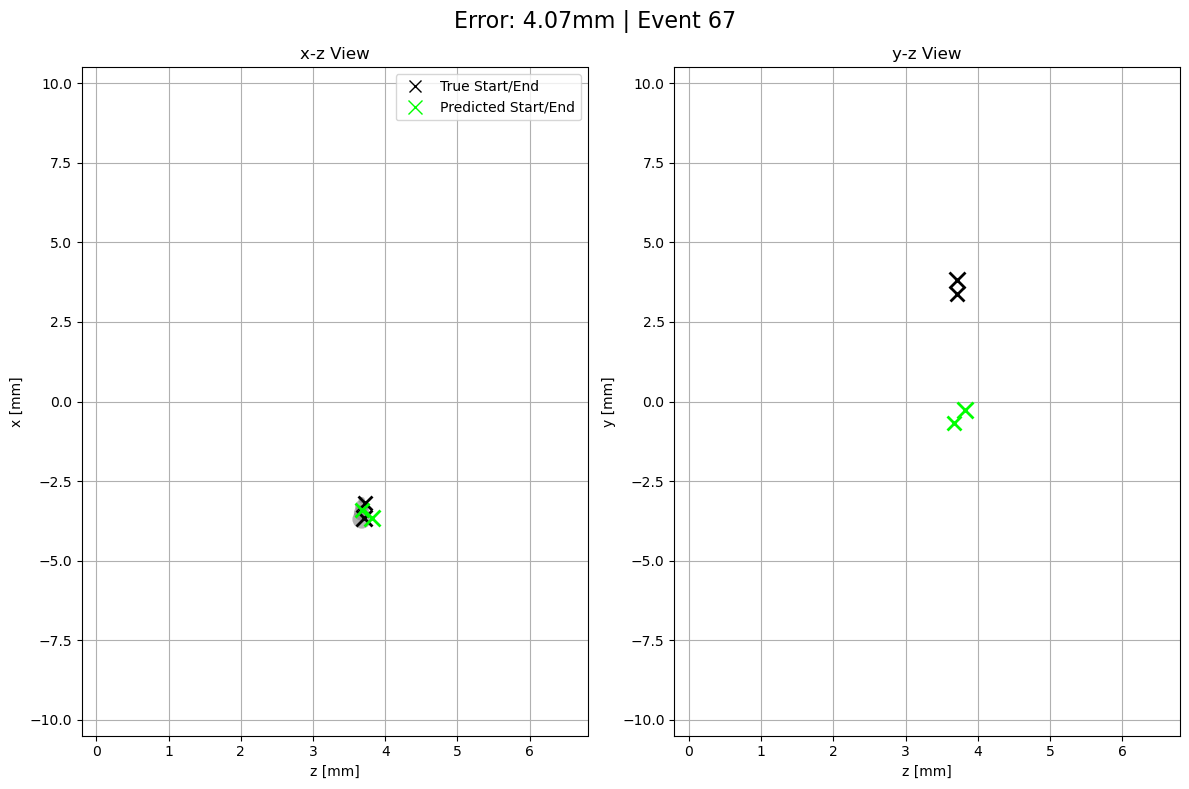


--- Failure 15 ---
Error: 3.9018 mm
Event ID: 91


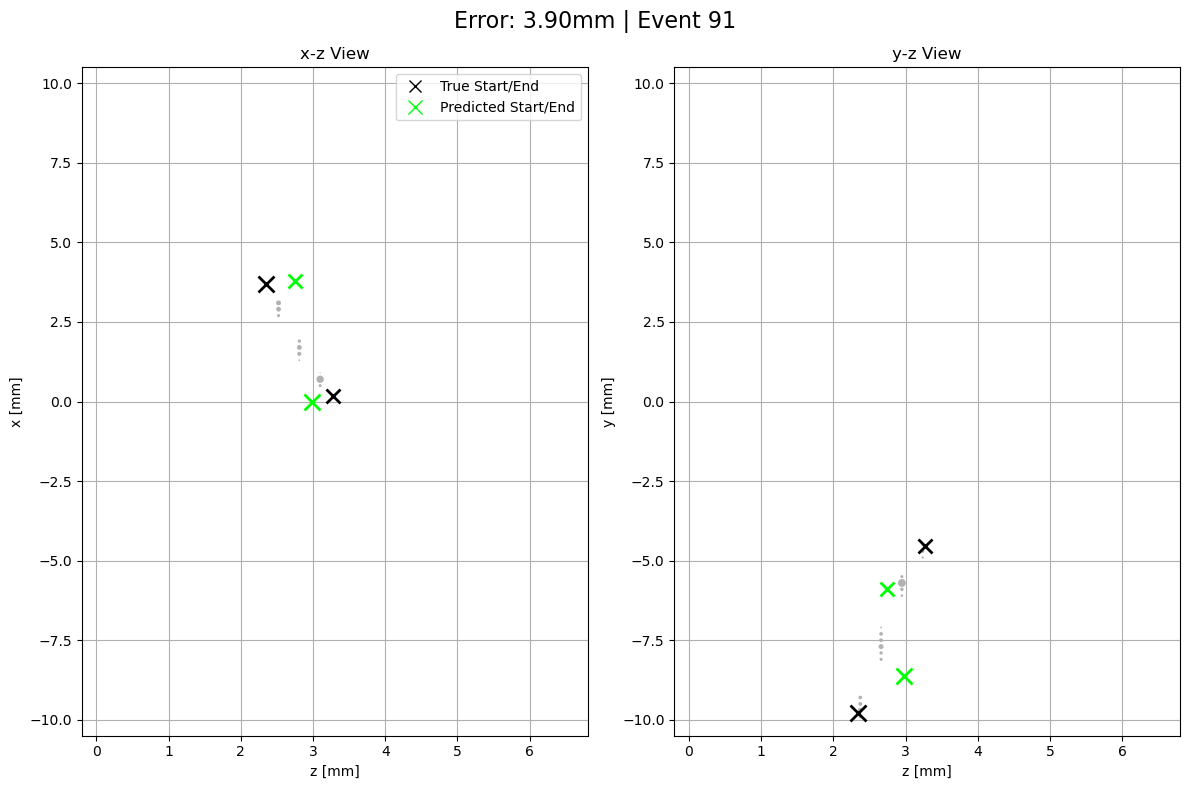


--- Failure 16 ---
Error: 3.7106 mm
Event ID: 277


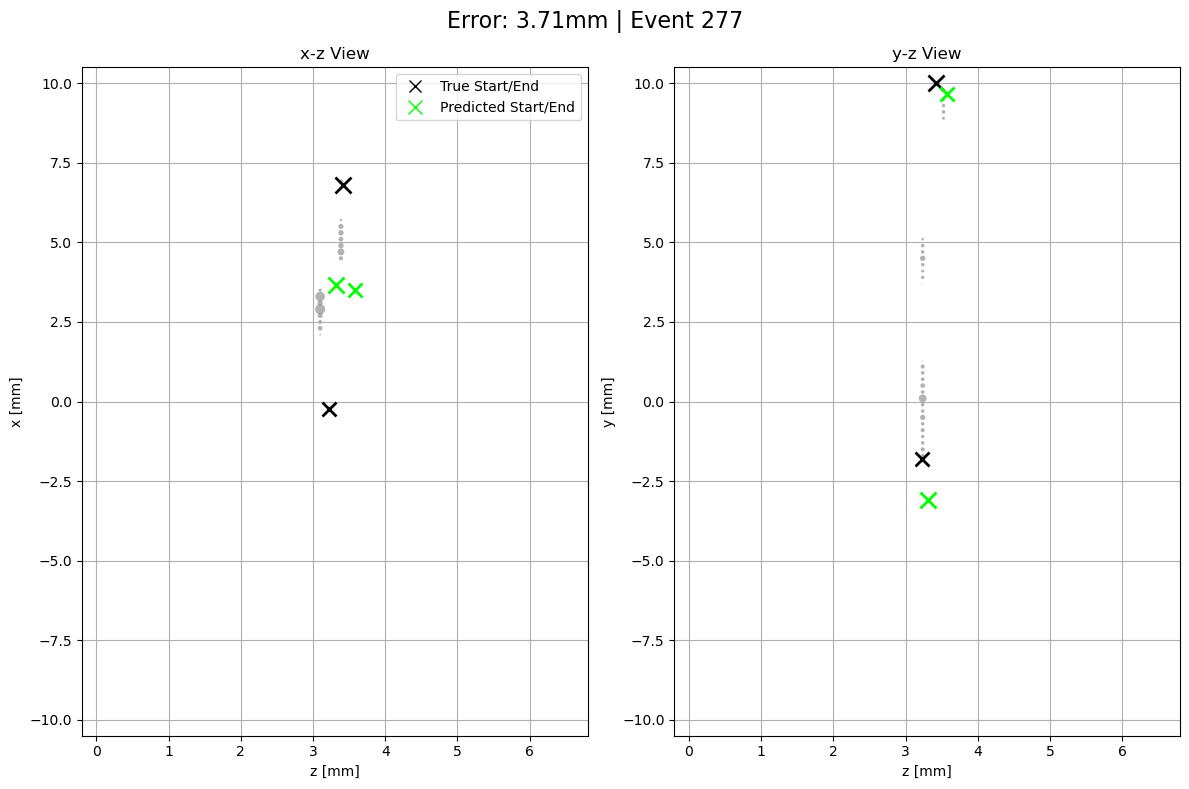


--- Failure 17 ---
Error: 3.7009 mm
Event ID: 109


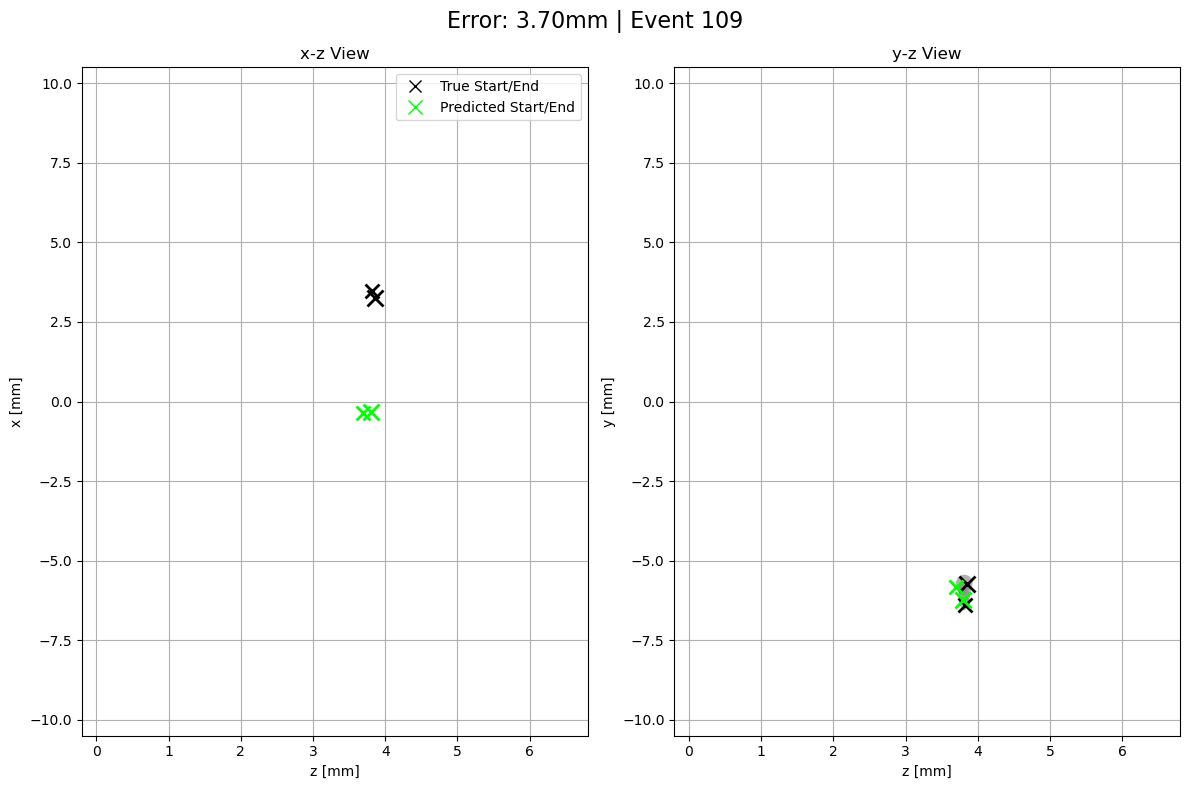


--- Failure 18 ---
Error: 3.5519 mm
Event ID: 181


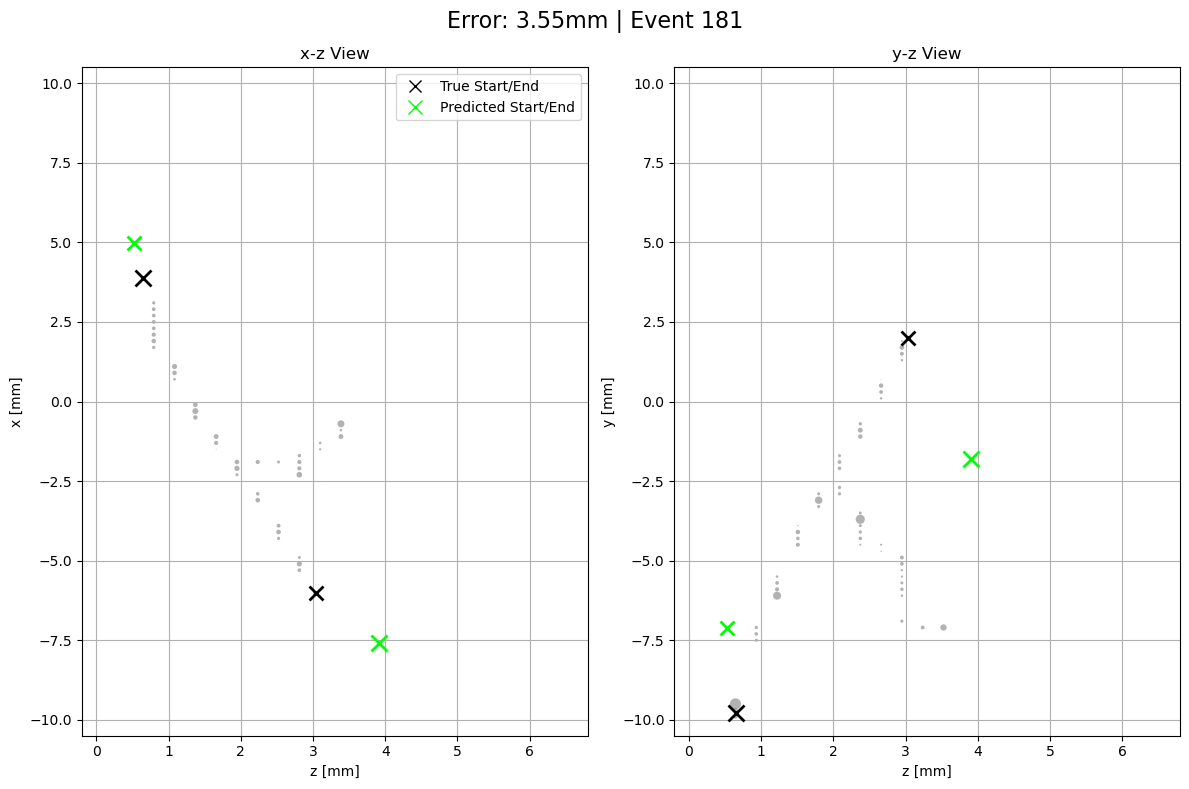


--- Failure 19 ---
Error: 3.1715 mm
Event ID: 307


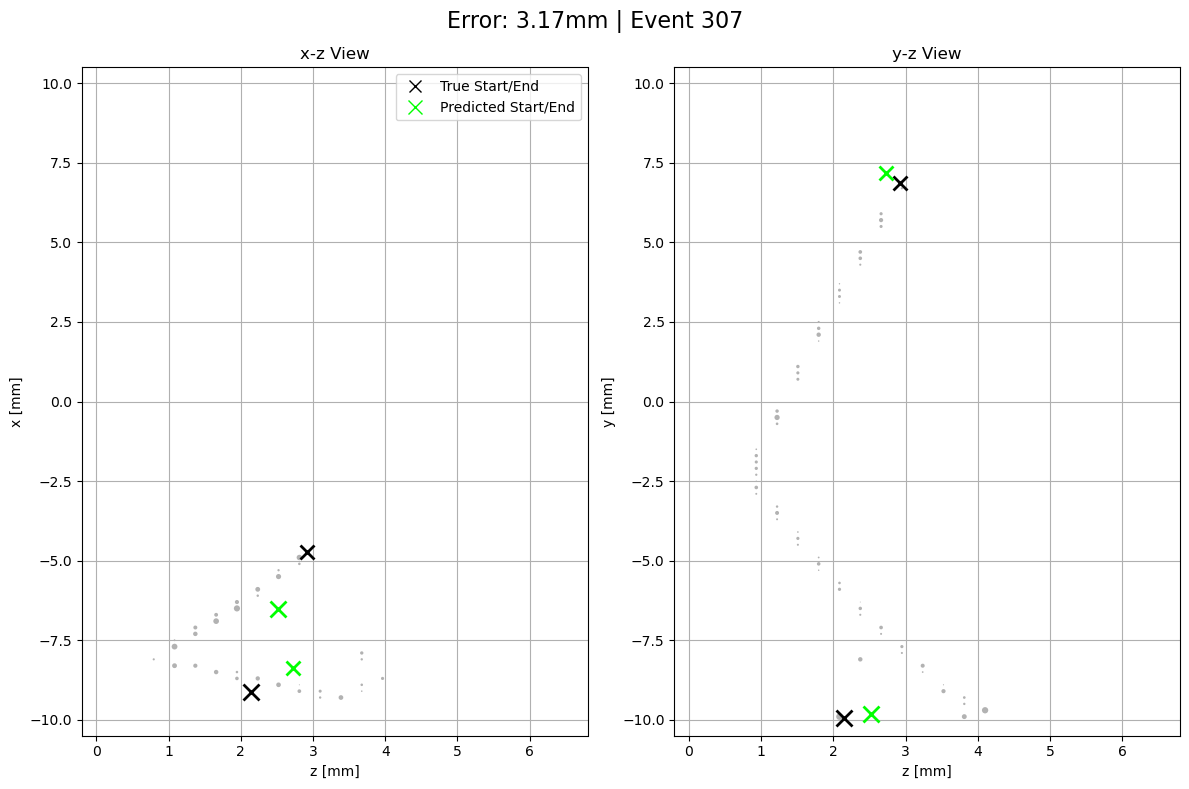


--- Failure 20 ---
Error: 3.1152 mm
Event ID: 61


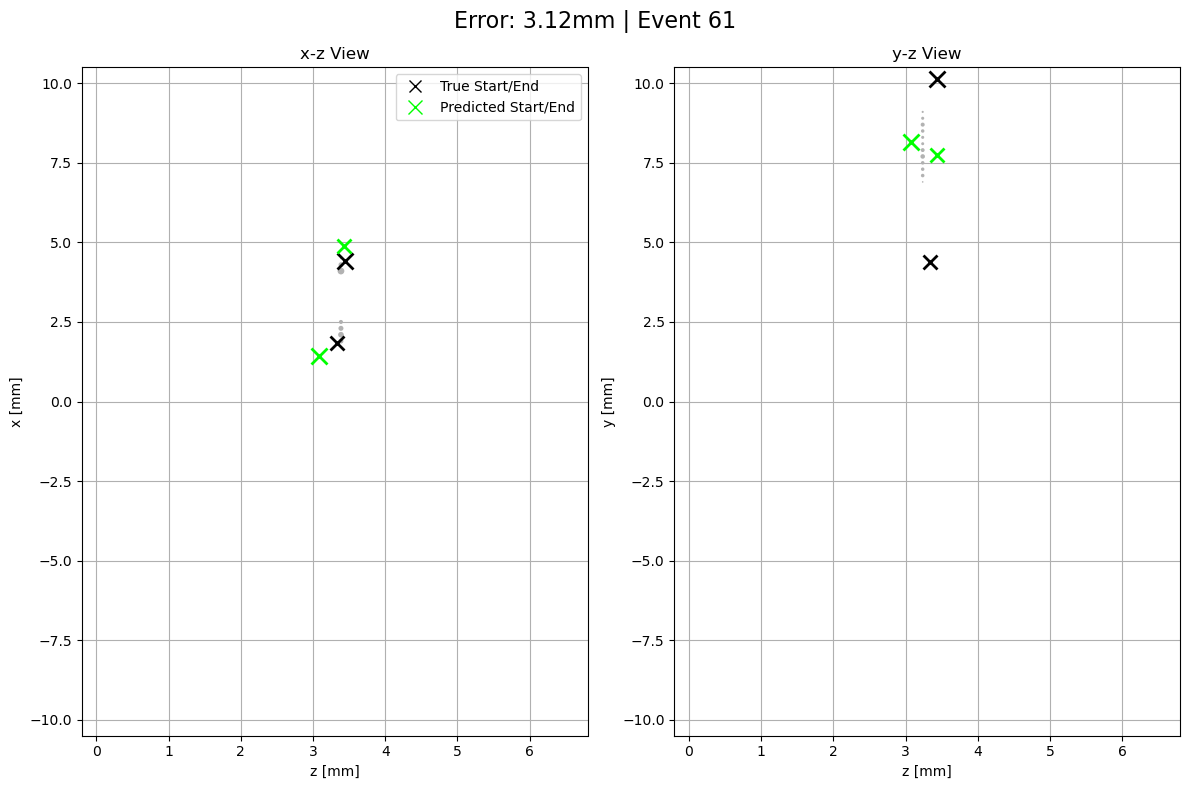


--- Failure 21 ---
Error: 2.9688 mm
Event ID: 193


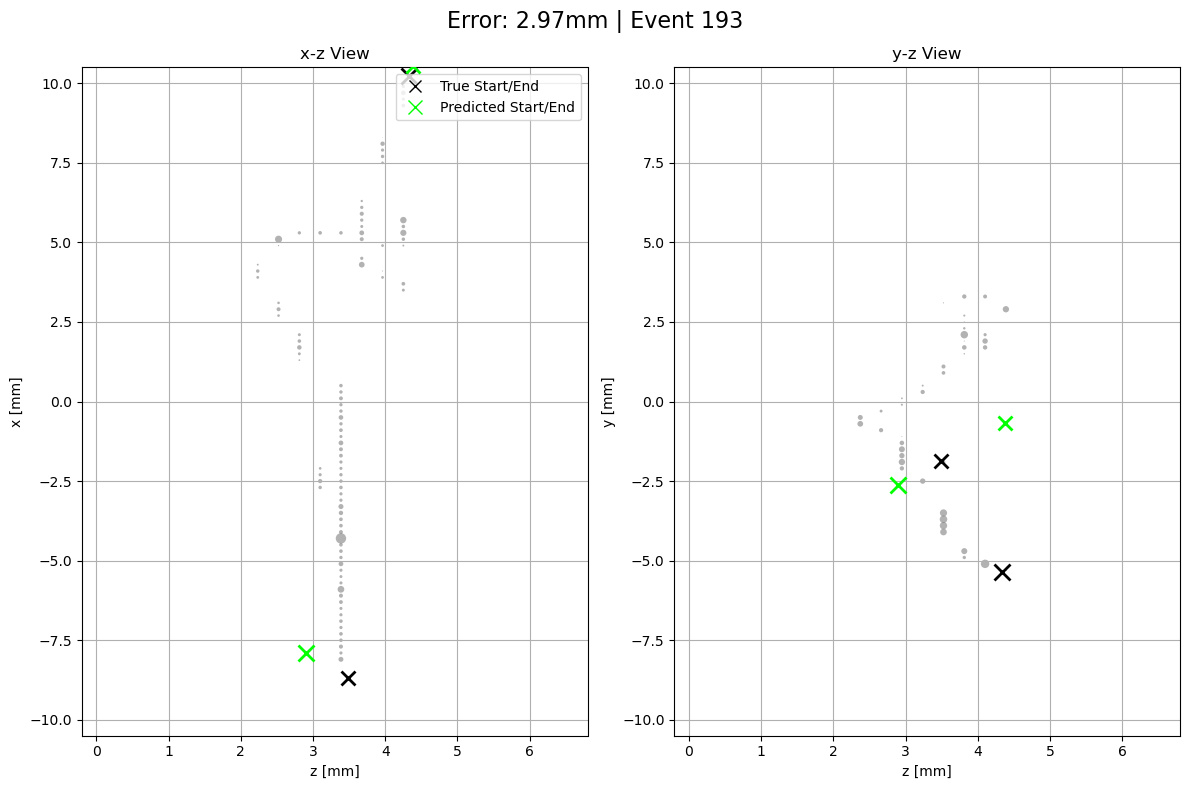


--- Failure 22 ---
Error: 2.9523 mm
Event ID: 239


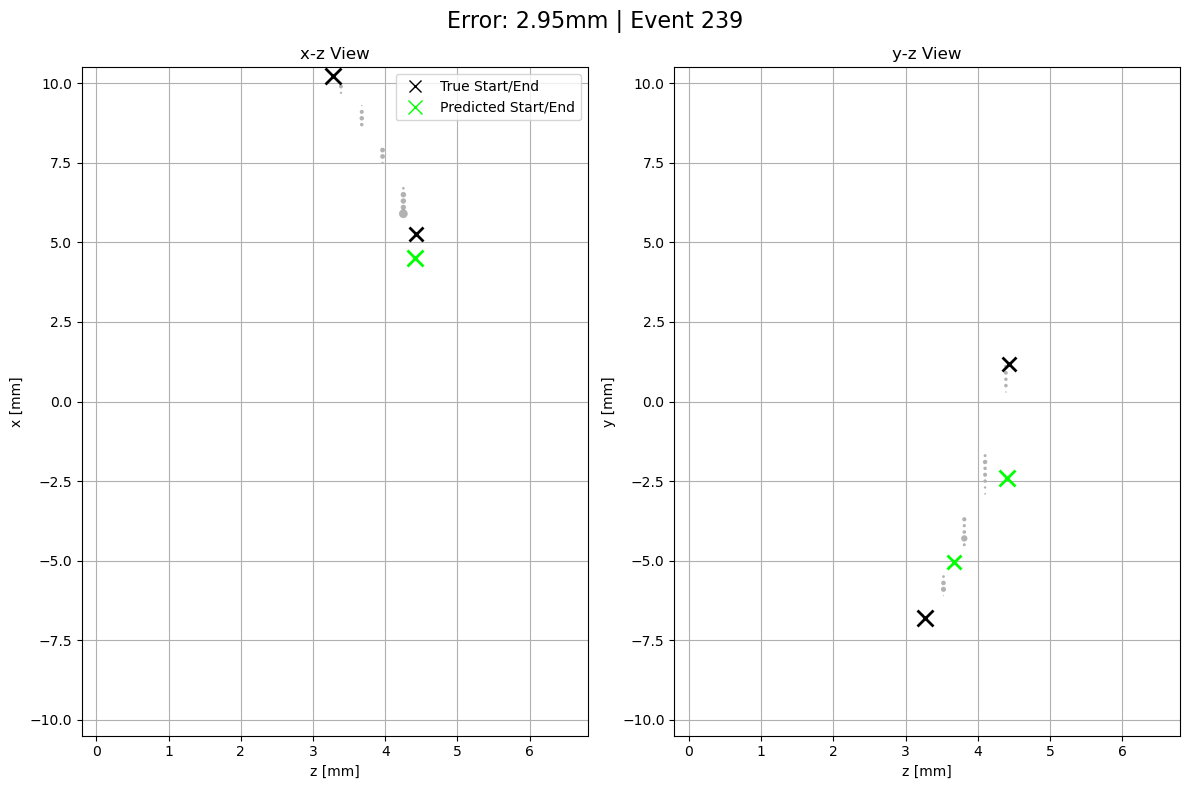


--- Failure 23 ---
Error: 2.9443 mm
Event ID: 222


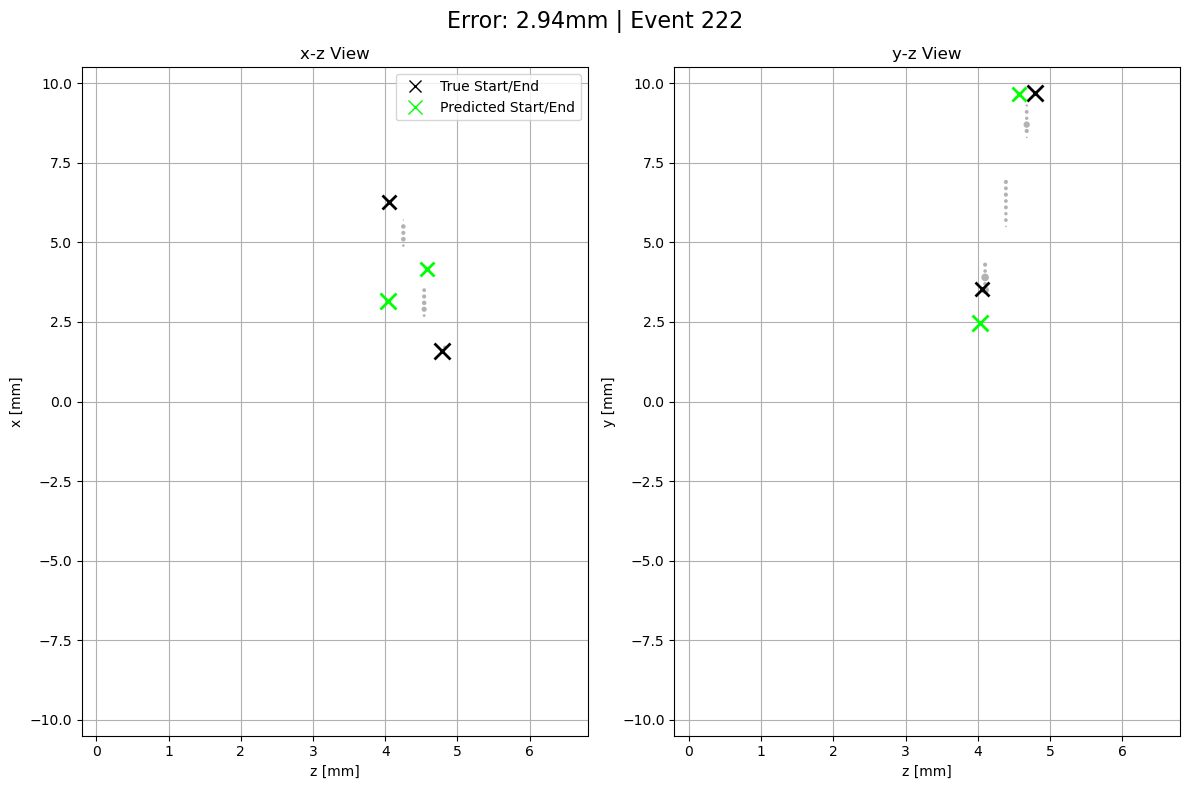


--- Failure 24 ---
Error: 2.8403 mm
Event ID: 220


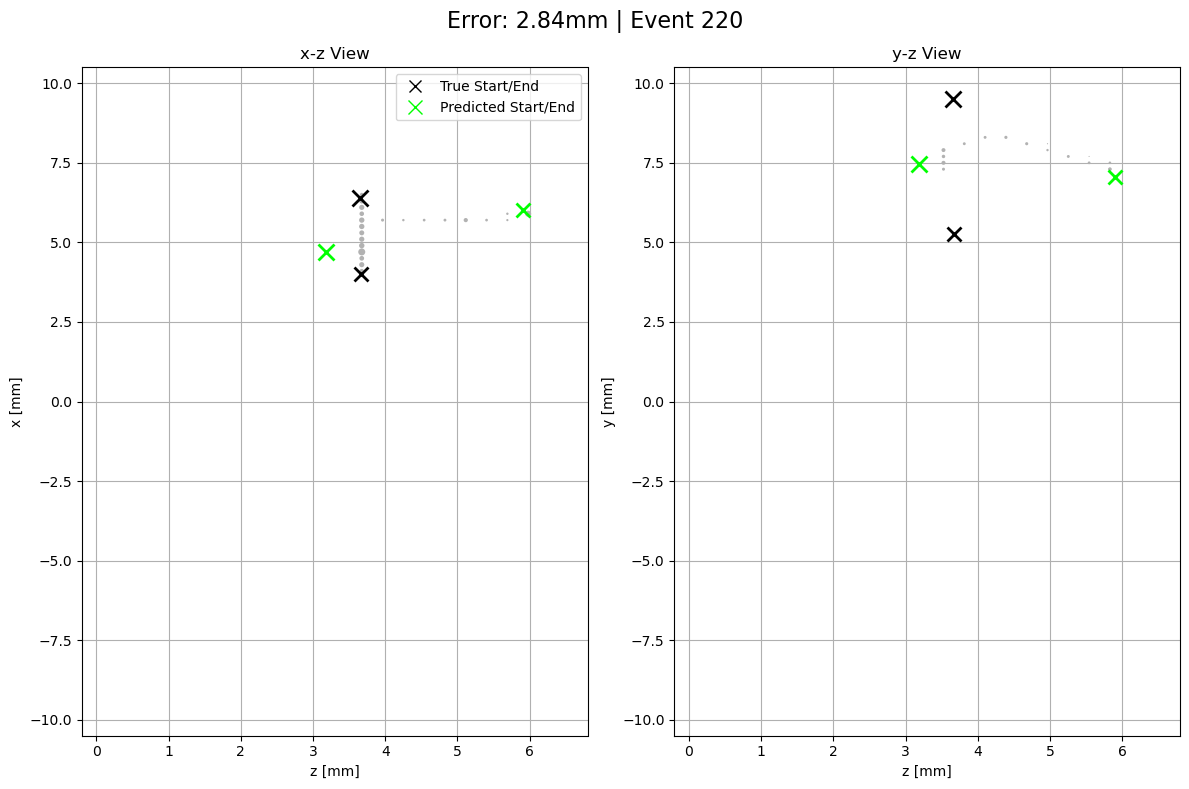


--- Failure 25 ---
Error: 2.8238 mm
Event ID: 318


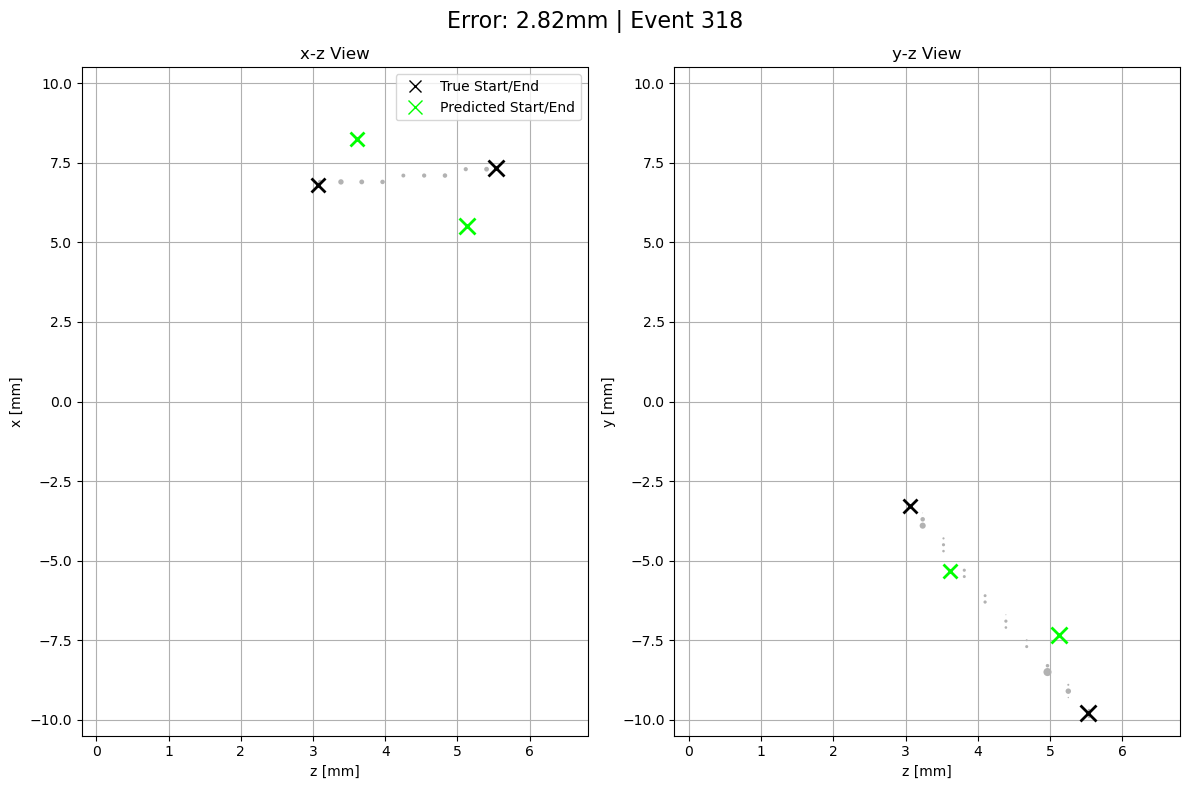


--- Failure 26 ---
Error: 2.7468 mm
Event ID: 184


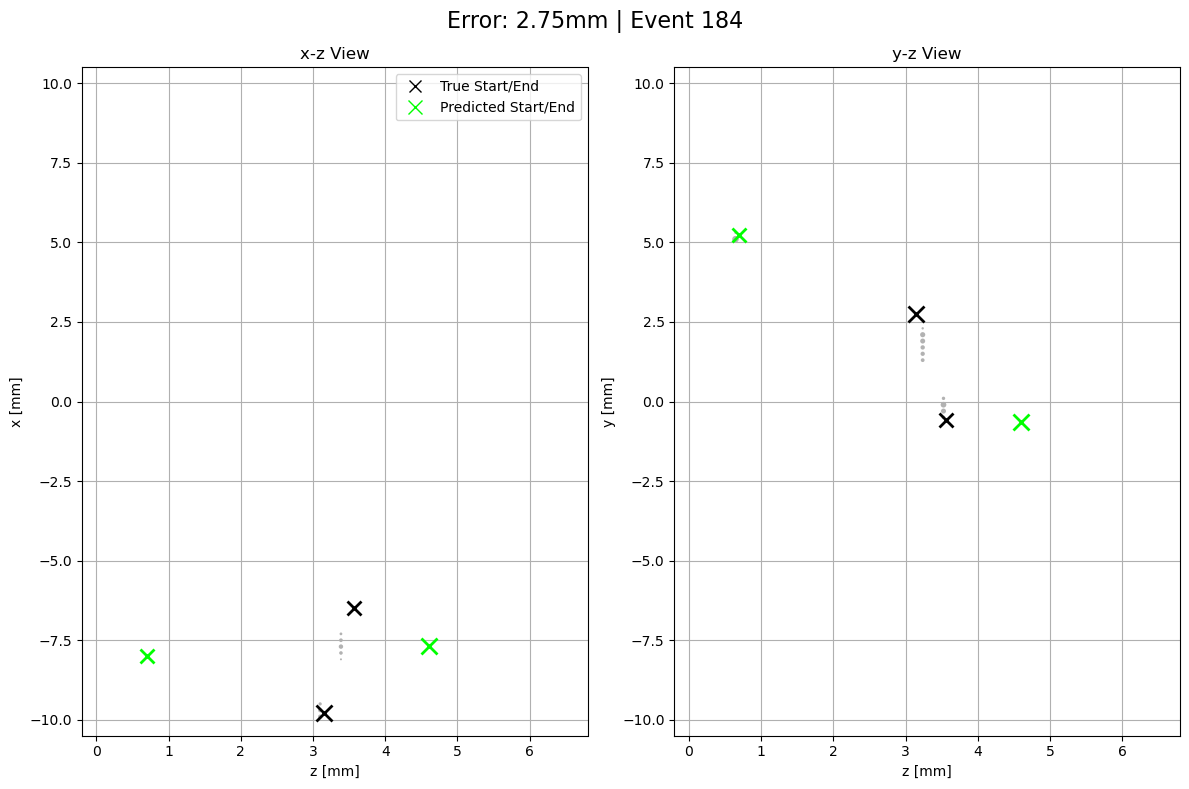


--- Failure 27 ---
Error: 2.7417 mm
Event ID: 116


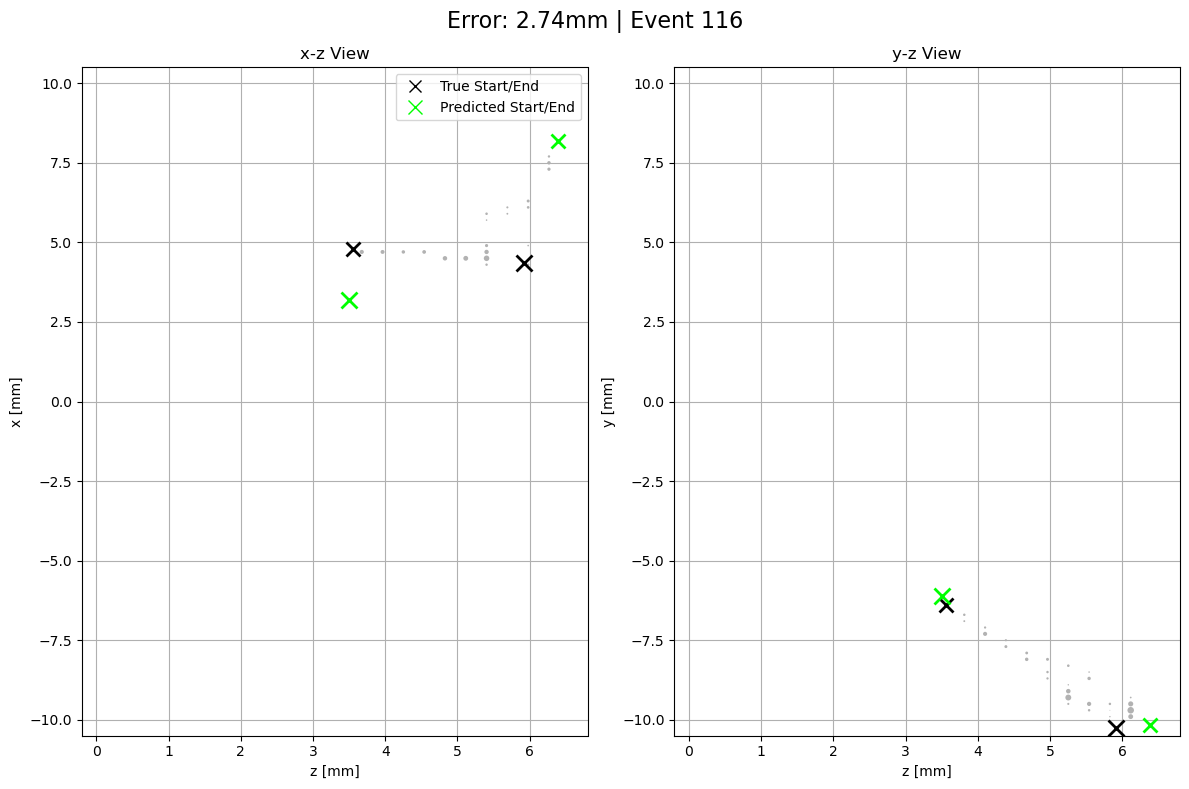


--- Failure 28 ---
Error: 2.7005 mm
Event ID: 264


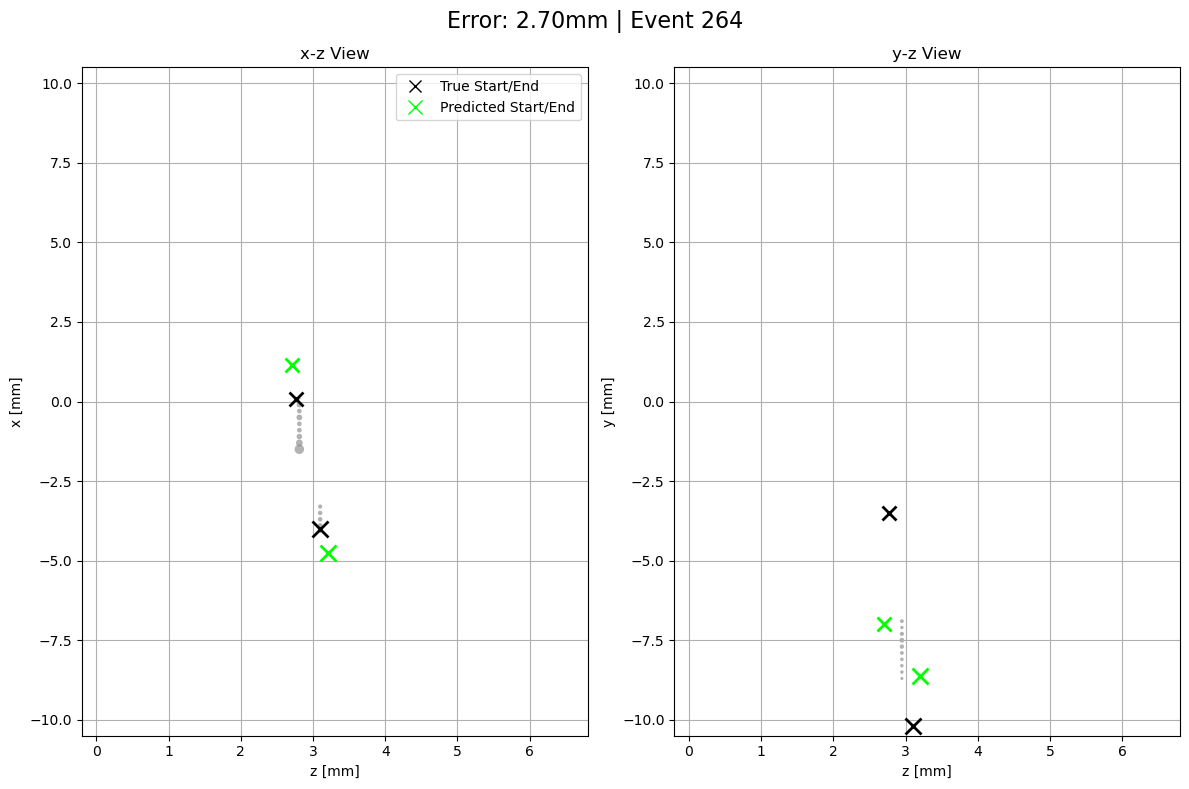


--- Failure 29 ---
Error: 2.6612 mm
Event ID: 305


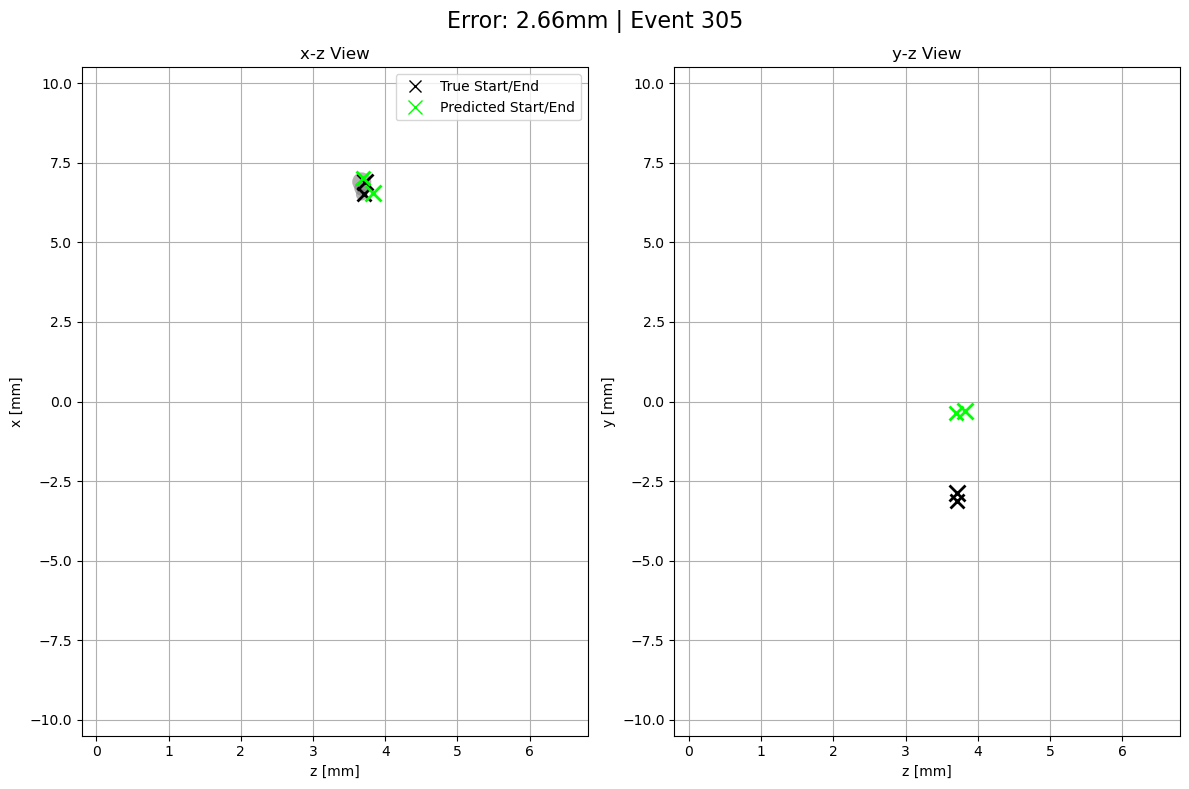


--- Failure 30 ---
Error: 2.6124 mm
Event ID: 331


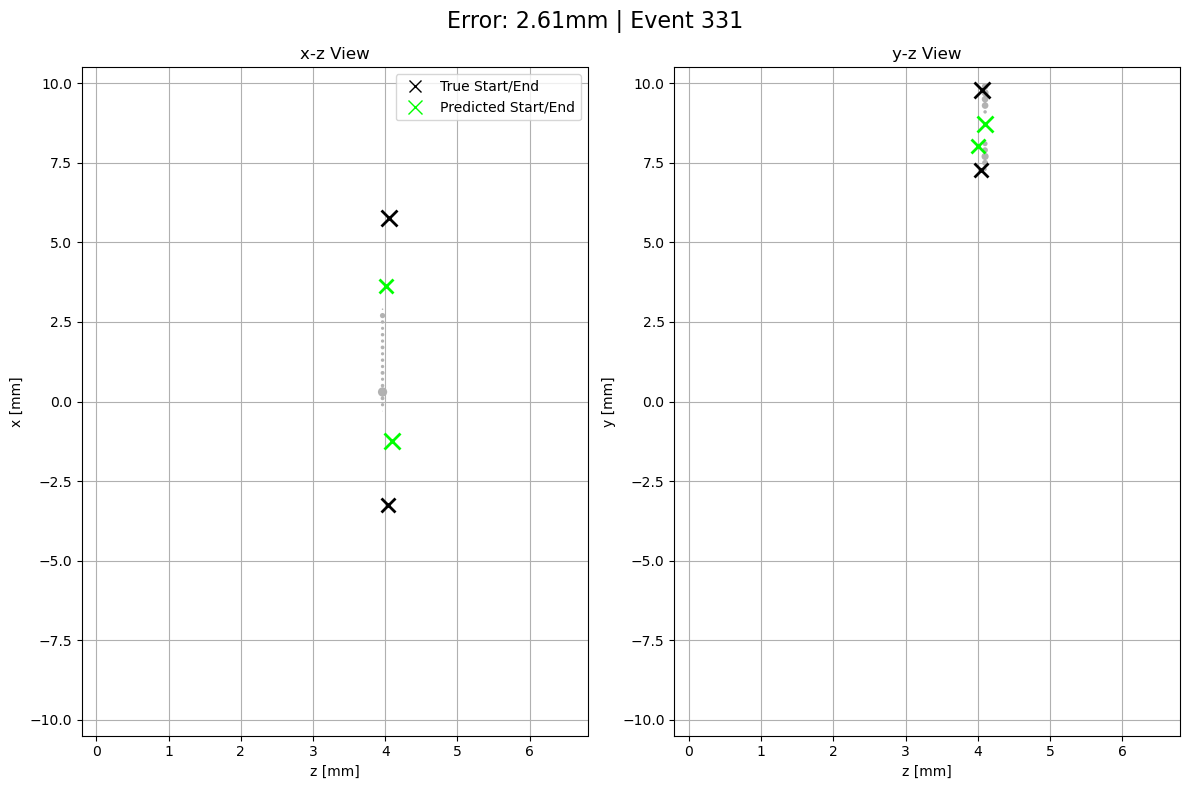


--- Failure 31 ---
Error: 2.5463 mm
Event ID: 120


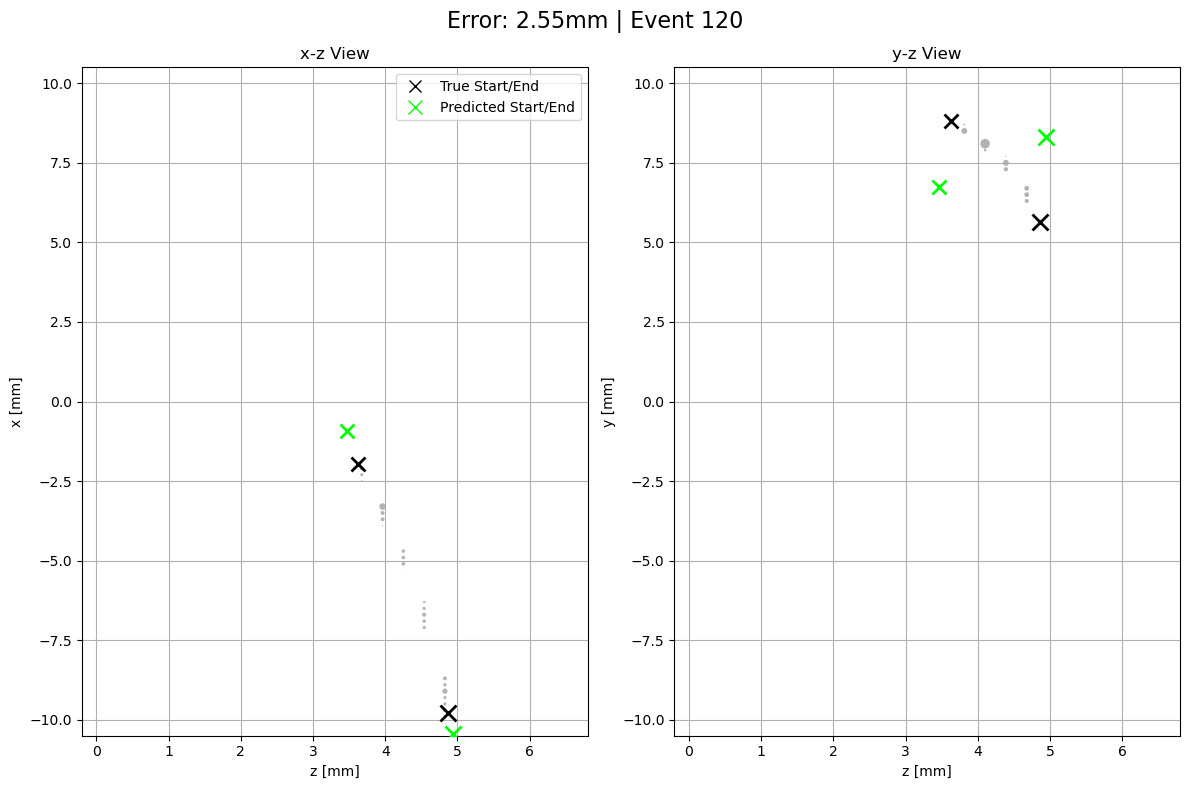


--- Failure 32 ---
Error: 2.4782 mm
Event ID: 101


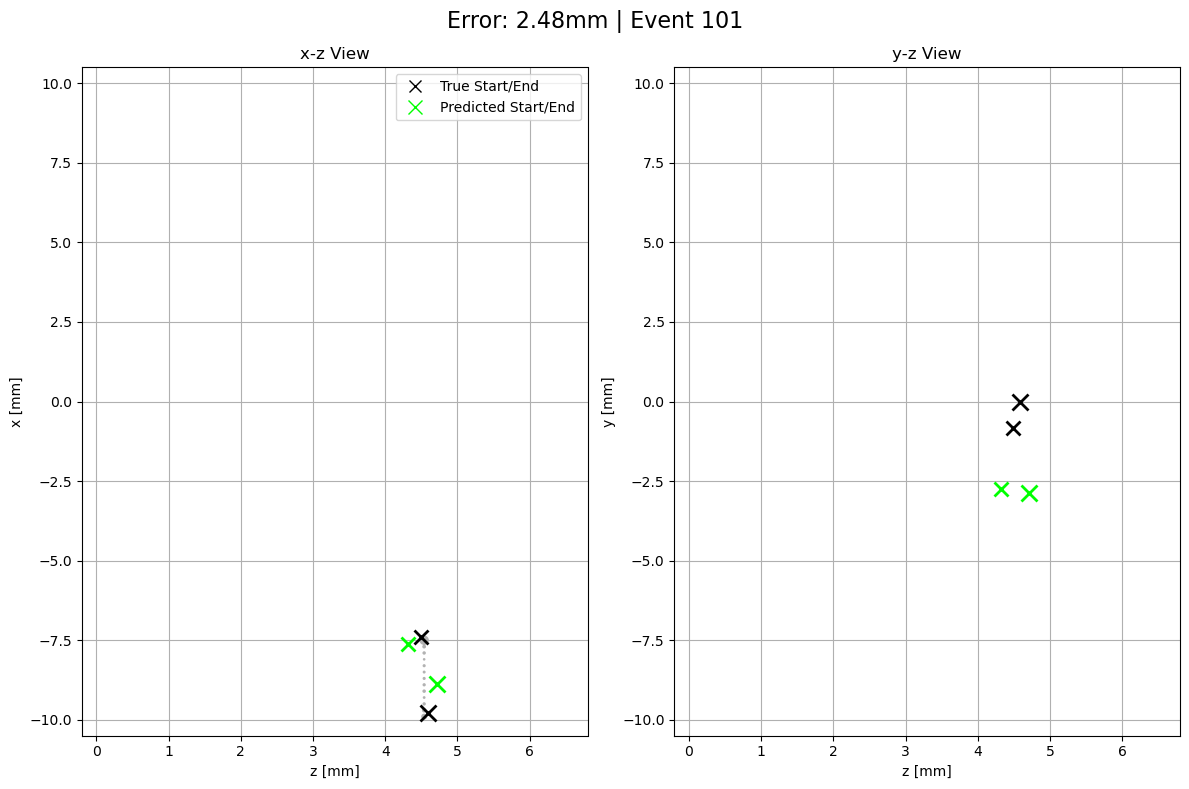


--- Failure 33 ---
Error: 2.4700 mm
Event ID: 284


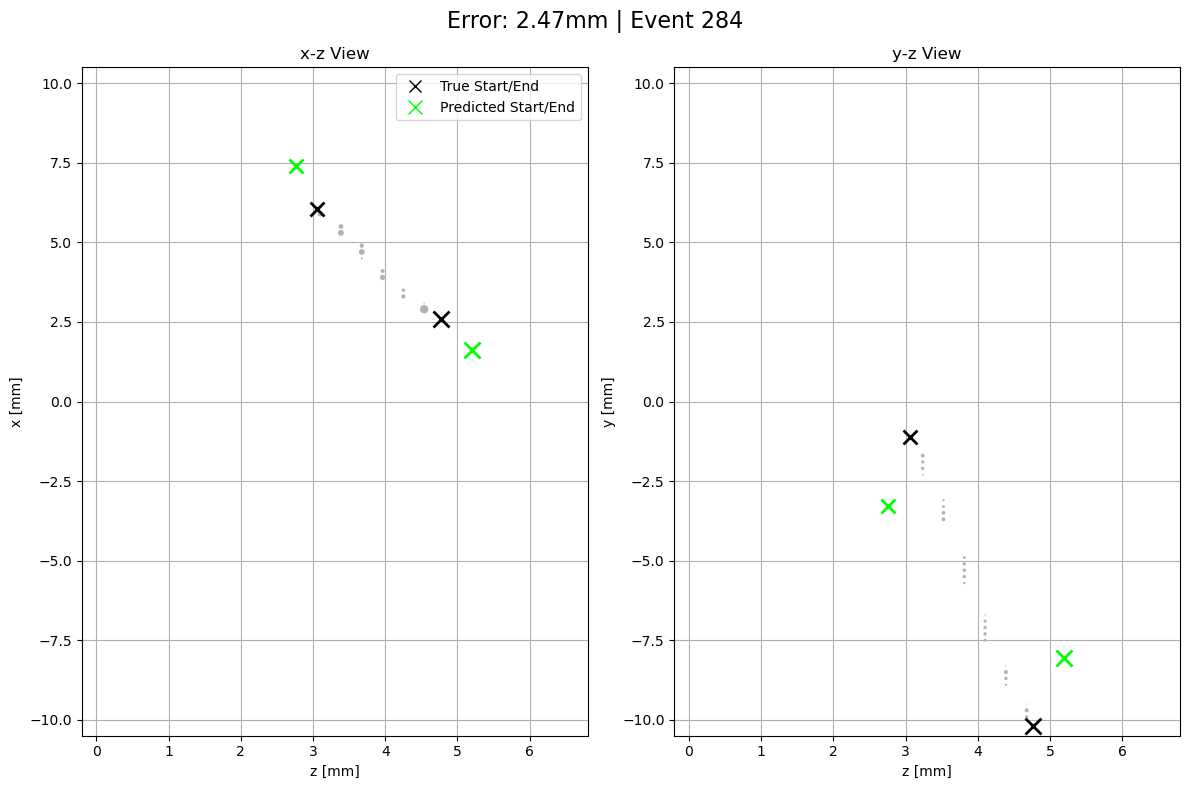


--- Failure 34 ---
Error: 2.3897 mm
Event ID: 24


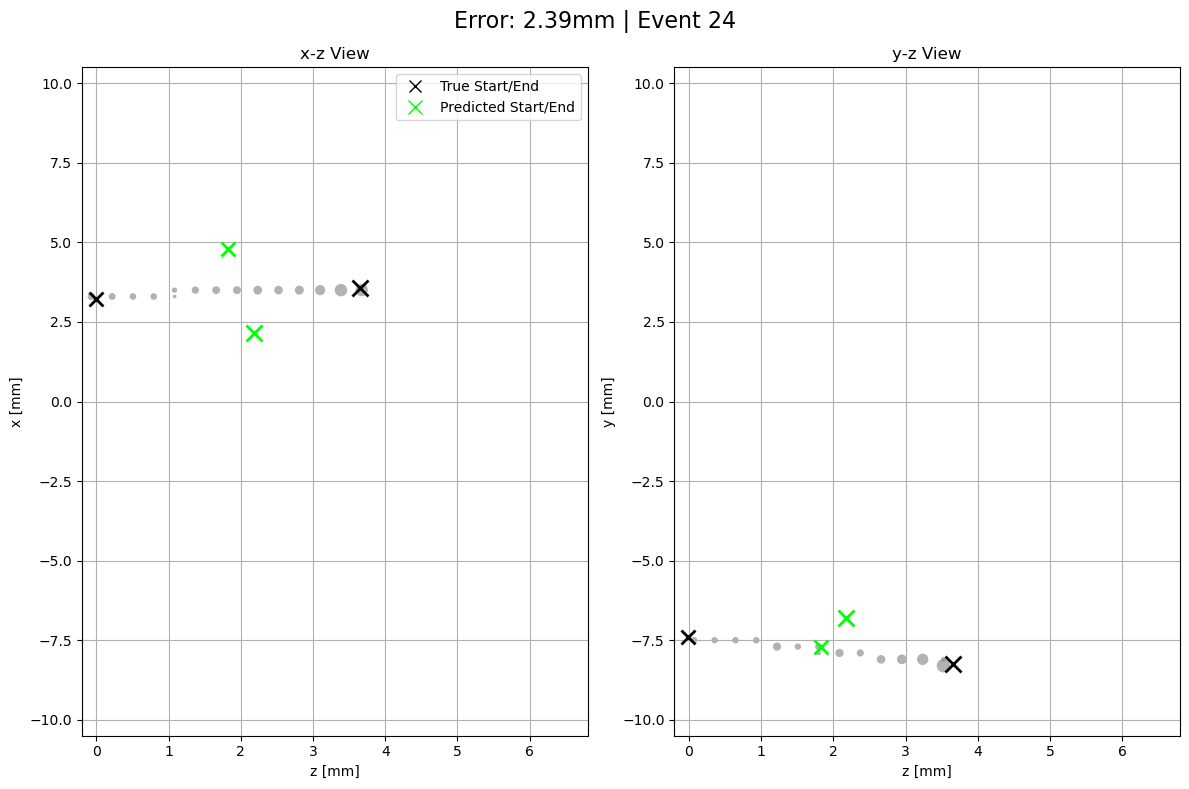


--- Failure 35 ---
Error: 2.3726 mm
Event ID: 69


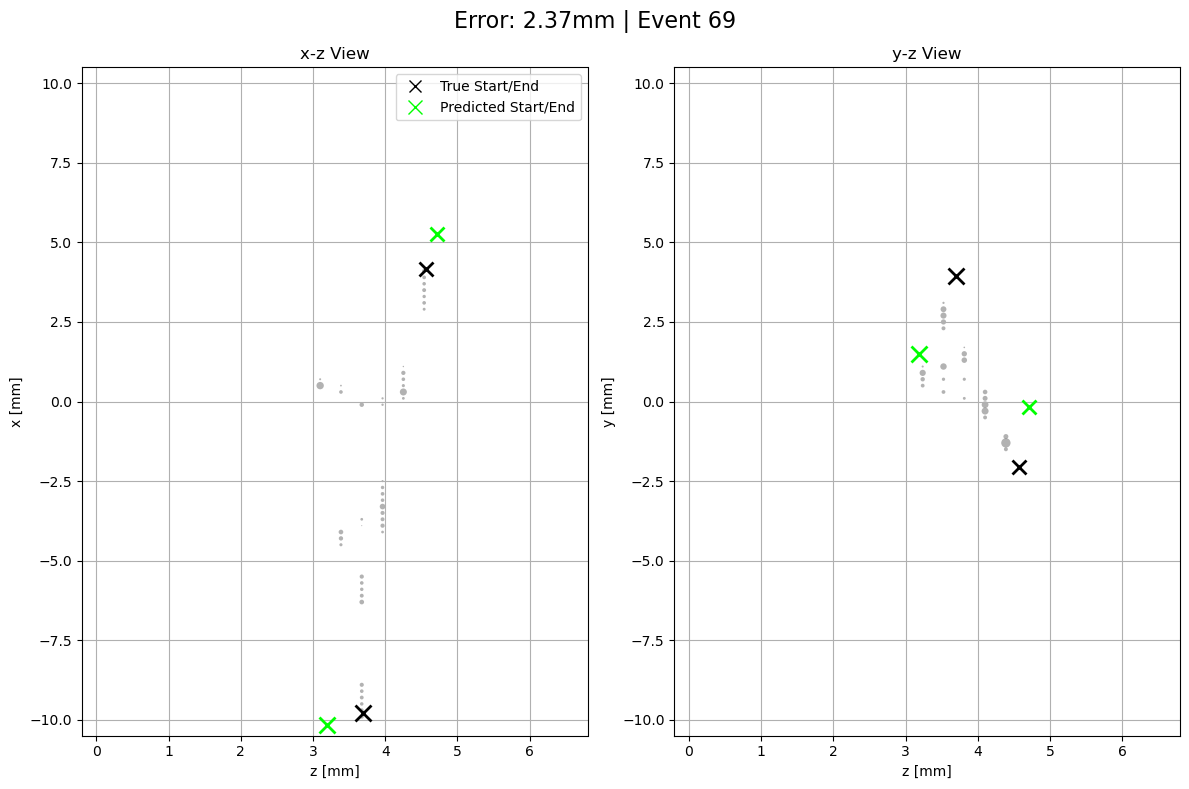

In [20]:
visualize_failures(model, test_loader, device='cuda', num_failures=35)